# Notebook 4 – Clusterização de Complexos Cinematográficos Brasileiros

**Objetivo**: Identificar possíveis perfis distintos de complexos cinematográficos e analisar sua relação com:
- Universalização do acesso a obras nacionais
- Diversificação da programação estrangeira

Em conformidade com o **Art. 6º da Lei da ANCINE** (incisos VII e VIII).

---

## Pipeline do Projeto

- **Notebook 0**: Ingestão e limpeza de sessões (2023–2025)
- **Notebook 0.5**: Enriquecimento com informações de produtoras/distribuidoras
- **Notebook 1**: EDA avançada por sessões/obras/complexos
- **Notebook 2**: Feature engineering por complexo (~50+ features)
- **Notebook 3**: Pré-processamento e seleção de features ✅
- **Notebook 4**: **Clusterização (ESTAMOS AQUI)** 🎯
- **Notebook 5**: Projeção/validação dos clusters em 2025

---

## Dados de Entrada

Artefatos produzidos no **Notebook 3** (pré-processamento):

1. **X_final_normalizado.npy**: Matriz (900, 75) com features normalizadas
2. **df_features_final.parquet**: DataFrame (900, 78) com IDs, metadados e features originais
3. **lista_final_de_features.json**: Lista ordenada das 75 features
4. **metadata_preprocessamento.json**: Metadados do pré-processamento


---

# 1. Setup e Carregamento

## 1.1 Importações

In [1]:
# Manipulação de dados
import numpy as np
import pandas as pd
import json
import pickle
from pathlib import Path
import os

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Configurações
import warnings
warnings.filterwarnings('ignore')

print("✅ Importações concluídas")

✅ Importações concluídas


In [2]:
%load_ext watermark
%watermark -a "Guilherme Gustavo Roca Arenales" --iversions

Author: Guilherme Gustavo Roca Arenales

pandas    : 2.3.3
scipy     : 1.16.3
json      : 2.0.9
sklearn   : 1.7.2
numpy     : 2.3.4
matplotlib: 3.10.8
seaborn   : 0.13.2



## 1.2 Configurações Gerais

In [3]:
# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Configurações definidas")

✅ Configurações definidas


## 1.3 Carregamento dos Dados

In [4]:
# Definir paths
BASES_DIR = Path('../Bases')

# Carregar matriz normalizada (entrada principal do clustering)
X_final = np.load(BASES_DIR / 'X_final_normalizado.npy')
print(f"✅ X_final_normalizado.npy carregado: shape {X_final.shape}")

# Carregar DataFrame com features originais e metadados
df_features = pd.read_parquet(BASES_DIR / 'df_features_final.parquet')
print(f"✅ df_features_final.parquet carregado: shape {df_features.shape}")

# Carregar lista de features (ordem das colunas em X_final)
with open(BASES_DIR / 'lista_final_de_features.json', 'r', encoding='utf-8') as f:
    features_info = json.load(f)
    feature_names = features_info['features']
print(f"✅ lista_final_de_features.json carregada: {len(feature_names)} features")

# Carregar metadata (opcional, para log)
with open(BASES_DIR / 'metadata_preprocessamento.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
print(f"✅ metadata_preprocessamento.json carregada")
print(f"   Processamento: {metadata.get('data_processamento', 'N/A')}")
print(f"   Notebook origem: {metadata.get('notebook', 'N/A')}")

✅ X_final_normalizado.npy carregado: shape (900, 75)
✅ df_features_final.parquet carregado: shape (900, 78)
✅ lista_final_de_features.json carregada: 75 features
✅ metadata_preprocessamento.json carregada
   Processamento: 2025-12-21T21:06:07.581801
   Notebook origem: Notebook_3_Preprocessamento.ipynb


## 1.4 Verificações Iniciais

In [5]:
# Verificar shapes
print("=" * 60)
print("VERIFICAÇÕES DE INTEGRIDADE")
print("=" * 60)

# Shape da matriz normalizada
n_complexos, n_features = X_final.shape
print(f"\n1. Matriz normalizada:")
print(f"   - Complexos: {n_complexos}")
print(f"   - Features: {n_features}")
print(f"   - Dtype: {X_final.dtype}")

# Shape do DataFrame
print(f"\n2. DataFrame tabular:")
print(f"   - Linhas: {len(df_features)}")
print(f"   - Colunas: {len(df_features.columns)}")

# Verificar se número de linhas coincide
assert n_complexos == len(df_features), "❌ ERRO: Número de complexos não coincide!"
print(f"   ✅ Número de linhas coincide entre X e DataFrame")

# Verificar se número de features coincide
assert n_features == len(feature_names), "❌ ERRO: Número de features não coincide!"
print(f"   ✅ Número de features coincide com lista_final_de_features.json")

# Verificar nulos na matriz
n_nulls = np.isnan(X_final).sum()
print(f"\n3. Valores nulos em X_final: {n_nulls}")
assert n_nulls == 0, "❌ ERRO: Matriz contém valores nulos!"
print(f"   ✅ Nenhum valor nulo encontrado")

# Verificar infinitos
n_inf = np.isinf(X_final).sum()
print(f"\n4. Valores infinitos em X_final: {n_inf}")
assert n_inf == 0, "❌ ERRO: Matriz contém valores infinitos!"
print(f"   ✅ Nenhum valor infinito encontrado")

# Verificar colunas chave no DataFrame
colunas_obrigatorias = ['REGISTRO_COMPLEXO', 'UF', 'municipio']
for col in colunas_obrigatorias:
    assert col in df_features.columns, f"❌ ERRO: Coluna {col} não encontrada!"
print(f"\n5. Colunas obrigatórias presentes: {colunas_obrigatorias}")
print(f"   ✅ Todas as colunas obrigatórias encontradas")

print("\n" + "=" * 60)
print("✅ TODAS AS VERIFICAÇÕES PASSARAM COM SUCESSO")
print("=" * 60)

VERIFICAÇÕES DE INTEGRIDADE

1. Matriz normalizada:
   - Complexos: 900
   - Features: 75
   - Dtype: float64

2. DataFrame tabular:
   - Linhas: 900
   - Colunas: 78
   ✅ Número de linhas coincide entre X e DataFrame
   ✅ Número de features coincide com lista_final_de_features.json

3. Valores nulos em X_final: 0
   ✅ Nenhum valor nulo encontrado

4. Valores infinitos em X_final: 0
   ✅ Nenhum valor infinito encontrado

5. Colunas obrigatórias presentes: ['REGISTRO_COMPLEXO', 'UF', 'municipio']
   ✅ Todas as colunas obrigatórias encontradas

✅ TODAS AS VERIFICAÇÕES PASSARAM COM SUCESSO


### Informações Adicionais do DataFrame

In [6]:
# Exibir primeiras linhas
print("\nPrimeiras 5 linhas do DataFrame:")
display(df_features.head())

# Exibir info
print("\nInformações do DataFrame:")
df_features.info()


Primeiras 5 linhas do DataFrame:


,REGISTRO_COMPLEXO,UF,municipio,num_salas_scaled,pct_dias_operando_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled,pct_sessoes_major_scaled,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_produtora_independente_scaled,produtora_nivel_medio_complexo_scaled,pct_sessoes_brasileiras_scaled,pct_sessoes_especiais_scaled,pct_modalidade_b_scaled,pct_modalidade_c_scaled,pct_modalidade_d_scaled,pct_sessoes_legendadas_scaled,pct_publico_obras_top5_scaled,pct_sessoes_obras_top5_scaled,populacao_scaled,pib_per_capita_scaled,ingressos_per_capita_municipio_scaled,entropia_nacionalidade_scaled,entropia_modalidade_scaled,entropia_faixa_horaria_scaled,entropia_distribuidora_scaled,obras_cinema_mundial_scaled,pct_obras_cinema_mundial_scaled,pct_obras_exclusivas_scaled,num_obras_ultranicho_scaled,pct_obras_ultranicho_scaled,pct_obras_nao_anglo_scaled,desproporcao_blockbuster_scaled,score_curadoria_scaled,intensidade_exibicao_scaled,perfil_independente_scaled,UF_AL,UF_AM,UF_AP,UF_BA,UF_CE,UF_DF,UF_ES,UF_GO,UF_MA,UF_MG,UF_MS,UF_MT,UF_PA,UF_PB,UF_PE,UF_PI,UF_PR,UF_RJ,UF_RN,UF_RO,UF_RR,UF_RS,UF_SC,UF_SE,UF_SP,UF_TO,porte_municipio_cat_Medio,porte_municipio_cat_Metropole,porte_municipio_cat_Muito_Grande,porte_municipio_cat_Pequeno,faixa_renda_cat_Baixa,faixa_renda_cat_Media_Alta,faixa_renda_cat_Media_Baixa,baixa_atividade,e_capital,operacao_nao_comercial,natureza_nao_informada,exibidor_independente,natureza_nao_privada,caso_extremo_atividade
0,11752,RJ,RIO DE JANEIRO,-0.0402,0.5773,0.3981,0.4799,0.0703,-0.1420,0.1979,0.2367,-0.1538,0.3032,-0.1510,-0.2180,-0.4224,-0.0464,-0.1530,2.2487,-0.4237,-0.4686,1.2497,0.1399,-0.8618,-0.1034,-0.5652,0.4639,0.5428,0.0542,0.0403,-0.1732,-0.1623,-0.1511,-0.0913,-0.1386,-0.0405,0.6510,-0.4965,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0,1,0,0,0,0,0
1,11818,ES,COLATINA,-0.7868,0.0165,-1.8739,-0.5166,0.3853,-0.2350,0.2396,0.0060,-0.2426,0.5451,-0.2324,-0.2503,-0.4224,-0.0464,-0.1530,-0.4652,0.5147,0.4857,-0.5097,-0.4590,-0.1943,-0.2801,-0.5652,-1.9894,0.4256,-0.7096,-0.5022,0.3184,-0.1623,-0.1511,-0.4483,0.2804,-0.3257,-0.8823,1.5690,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0,0,0,0,1,0,0
2,11840,SP,SÃO PAULO,1.8262,0.5963,0.7041,1.1111,0.0795,-0.1499,0.1698,0.1372,-0.2771,0.4802,-0.1735,-0.1951,-0.4224,-0.0464,-0.1530,1.7639,-0.1335,-0.0652,2.7636,0.5449,-0.8081,-0.0945,-0.5652,1.3209,0.4454,0.6170,0.1021,-0.1732,-0.1623,-0.1511,-0.0745,-0.1542,0.0090,0.8341,-0.5341,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,1,0,0,0,0,0
3,12006,MG,SÃO JOÃO DEL REI,-1.1601,0.1448,0.0583,-0.6696,0.3464,-0.2350,0.3186,0.3361,-0.1514,0.5426,-0.3545,-0.2503,0.6606,-0.0464,-0.1296,0.2603,-0.1639,-0.3297,-0.5184,-0.5479,-0.2555,-0.4543,0.4139,0.0943,0.2958,-0.8704,-0.8907,-0.1732,-0.1623,-0.1511,-0.7518,0.1455,-0.7842,0.0991,1.5955,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0,0,0,0,1,0,0
4,12036,PR,CURITIBA,-0.0402,0.3254,0.8514,0.4796,-1.3323,-0.1699,0.0307,0.2620,-0.8181,0.8900,-0.8776,-0.2503,-0.4085,-0.0464,-0.1530,3.2565,-2.1235,-2.3235,-0.0321,0.0658,-0.9083,-1.3676,-0.5440,-0.1102,-0.2619,2.1044,2.6152,2.1946,3.3057,1.7505,0.7680,-0.7281,2.9874,0.6494,1.4165,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 78 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   REGISTRO_COMPLEXO                          900 non-null    object 
 1   UF                                         900 non-null    object 
 2   municipio                                  900 non-null    object 
 3   num_salas_scaled                           900 non-null    float64
 4   pct_dias_operando_scaled                   900 non-null    float64
 5   sessoes_por_dia_sala_scaled                900 non-null    float64
 6   volume_log_scaled                          900 non-null    float64
 7   pct_sessoes_major_scaled                   900 non-null    float64
 8   pct_sessoes_distrib_independente_scaled    900 non-null    float64
 9   porte_medio_distribuidora_scaled           900 non-null    float64
 10 

**Interpretação**: Temos 900 complexos cinematográficos com 75 features normalizadas prontas para clustering. O DataFrame complementar contém IDs, localização geográfica e as features originais (não-escaladas) que usaremos para interpretar os clusters.

---

# 2. Diagnóstico Rápido do Espaço de Features

## 2.1 Estatísticas Básicas das Features Normalizadas

In [7]:
# Converter matriz para DataFrame para facilitar análise
X_df = pd.DataFrame(X_final, columns=feature_names)

# Estatísticas descritivas
print("Estatísticas das features normalizadas (primeiras 10):")
display(X_df.iloc[:, :10].describe())

# Verificar distribuição geral
print("\nResumo geral:")
print(f"Média global: {X_df.mean().mean():.6f} (esperado ≈ 0 para features escaladas)")
print(f"Desvio padrão global: {X_df.std().mean():.6f} (esperado ≈ 1 para features escaladas)")
print(f"Min global: {X_df.min().min():.2f}")
print(f"Max global: {X_df.max().max():.2f}")

Estatísticas das features normalizadas (primeiras 10):


,num_salas_scaled,pct_dias_operando_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled,pct_sessoes_major_scaled,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_produtora_independente_scaled,produtora_nivel_medio_complexo_scaled
count,900.0000,900.0000,900.0000,900.0000,900.0000,900.0000,900.0000,900.0000,900.0000,900.0000
mean,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006
min,-1.1601,-2.8543,-4.1422,-5.2197,-4.4042,-0.2350,-15.5239,-10.9971,-0.8698,-7.8603
25%,-0.7868,-0.0643,-0.5854,-0.4959,-0.0449,-0.2350,0.1190,0.1552,-0.3096,-0.0610
50%,-0.0402,0.5607,0.2183,0.2715,0.1741,-0.1628,0.1948,0.2424,-0.1904,0.2410
75%,0.7064,0.5868,0.7345,0.7161,0.4837,-0.0969,0.2556,0.2995,-0.0470,0.4302
max,5.1859,0.5963,2.4656,1.5281,1.6236,18.6377,0.3414,0.3361,13.6804,2.5740



Resumo geral:
Média global: 0.042237 (esperado ≈ 0 para features escaladas)
Desvio padrão global: 0.582146 (esperado ≈ 1 para features escaladas)
Min global: -15.52
Max global: 29.25


### 2.1.1 Investigação de complexos extremamente outliers

In [8]:
# Investigar usando a matriz normalizada
print("=" * 70)
print("INVESTIGAÇÃO DO OUTLIER EXTREMO")
print("=" * 70)

# Encontrar o índice do outlier na matriz normalizada
feature_idx = feature_names.index('pct_sessoes_distrib_independente_scaled')
outlier_row_idx = X_final[:, feature_idx].argmax()

print(f"\nÍndice do outlier: {outlier_row_idx}")
print(f"Valor normalizado: {X_final[outlier_row_idx, feature_idx]:.4f}")

# Buscar informações do complexo no DataFrame
complexo_outlier = df_features.iloc[outlier_row_idx]

print(f"\nComplexo: {complexo_outlier['REGISTRO_COMPLEXO']}")
print(f"Município: {complexo_outlier['municipio']}")
print(f"UF: {complexo_outlier['UF']}")

# Outras características disponíveis
print(f"\n--- CARACTERÍSTICAS DO COMPLEXO ---")
for col in ['num_salas', 'volume_log', 'pct_dias_operando', 
            'pct_sessoes_brasileiras', 'pct_sessoes_major',
            'baixa_atividade', 'e_capital', 'operacao_nao_comercial']:
    if col in df_features.columns:
        val = complexo_outlier[col]
        if isinstance(val, (int, np.integer)):
            print(f"{col}: {val}")
        elif isinstance(val, (float, np.floating)):
            print(f"{col}: {val:.4f}")

# Distribuição da feature normalizada
print(f"\n--- DISTRIBUIÇÃO DA FEATURE NORMALIZADA ---")
feature_values = X_final[:, feature_idx]
print(f"Média: {feature_values.mean():.4f}")
print(f"Std: {feature_values.std():.4f}")
print(f"Min: {feature_values.min():.4f}")
print(f"Max: {feature_values.max():.4f}")
print(f"Mediana: {np.median(feature_values):.4f}")
print(f"P95: {np.percentile(feature_values, 95):.4f}")
print(f"P99: {np.percentile(feature_values, 99):.4f}")

print(f"\n⚠️ Este complexo está a {feature_values.max():.1f} desvios padrão da média!")
print(f"   (P99 está em {np.percentile(feature_values, 99):.2f}, ele está MUITO além disso)")

INVESTIGAÇÃO DO OUTLIER EXTREMO

Índice do outlier: 104
Valor normalizado: 18.6377

Complexo: 17778
Município: ARCOS
UF: MG

--- CARACTERÍSTICAS DO COMPLEXO ---
baixa_atividade: 1
e_capital: 0
operacao_nao_comercial: 0

--- DISTRIBUIÇÃO DA FEATURE NORMALIZADA ---
Média: -0.0000
Std: 1.0000
Min: -0.2350
Max: 18.6377
Mediana: -0.1628
P95: 0.7480
P99: 2.8094

⚠️ Este complexo está a 18.6 desvios padrão da média!
   (P99 está em 2.81, ele está MUITO além disso)


In [9]:
# Investigar mais profundamente o complexo outlier
print("=" * 70)
print("ANÁLISE DETALHADA DO COMPLEXO OUTLIER")
print("=" * 70)

complexo_id = '17778'
print(f"\nComplexo: {complexo_id}")
print(f"Município: ARCOS / MG")
print(f"Status: BAIXA ATIVIDADE = 1")

# Buscar TODAS as colunas deste complexo
print("\n--- TODAS AS CARACTERÍSTICAS DISPONÍVEIS ---")
outlier_data = df_features.iloc[104]

# Organizar por categorias
print("\n📊 VOLUME E ATIVIDADE:")
for col in ['num_salas', 'volume_log', 'pct_dias_operando', 'sessoes_por_dia_sala']:
    if col in df_features.columns:
        print(f"  {col}: {outlier_data[col]}")

print("\n🎬 PROGRAMAÇÃO:")
for col in ['pct_sessoes_brasileiras', 'pct_sessoes_major', 
            'pct_sessoes_com_distribuidor', 'pct_sessoes_legendadas']:
    if col in df_features.columns:
        print(f"  {col}: {outlier_data[col]}")

print("\n🏢 CARACTERÍSTICAS OPERACIONAIS:")
for col in ['natureza_nao_privada', 'natureza_nao_informada', 
            'exibidor_independente', 'caso_extremo_atividade']:
    if col in df_features.columns:
        print(f"  {col}: {outlier_data[col]}")

# Buscar no arquivo original do Notebook 2 para pegar valor bruto
print("\n" + "=" * 70)
print("BUSCANDO VALOR ORIGINAL NO ARQUIVO DO NOTEBOOK 2")
print("=" * 70)

try:
    # Tentar carregar o arquivo original
    df_original = pd.read_parquet('../Bases/df_complexos_features.parquet')
    
    if complexo_id in df_original['REGISTRO_COMPLEXO'].values:
        outlier_original = df_original[df_original['REGISTRO_COMPLEXO'] == complexo_id].iloc[0]
        
        print(f"\n✅ VALOR ORIGINAL encontrado:")
        print(f"  pct_sessoes_distrib_independente: {outlier_original['pct_sessoes_distrib_independente']:.4f}")
        
        # Mostrar contexto completo
        print(f"\n  Contexto adicional:")
        print(f"  - pct_sessoes_major: {outlier_original['pct_sessoes_major']:.4f}")
        print(f"  - pct_sessoes_brasileiras: {outlier_original['pct_sessoes_brasileiras']:.4f}")
        print(f"  - total_sessoes: {outlier_original.get('total_sessoes', 'N/A')}")
        print(f"  - publico_total: {outlier_original.get('publico_total', 'N/A')}")
        
except Exception as e:
    print(f"⚠️ Não foi possível carregar arquivo original: {e}")
    print("\nMas sabemos que:")
    print("  - Está marcado como BAIXA ATIVIDADE")
    print("  - Valor normalizado é 18.6 desvios padrão acima da média")
    print("  - P99 da distribuição é apenas 2.81")
    print("  - Isso sugere valor original próximo a 100% (1.0)")

# Comparar com outros complexos de baixa atividade
print("\n" + "=" * 70)
print("COMPARAÇÃO COM OUTROS COMPLEXOS DE BAIXA ATIVIDADE")
print("=" * 70)

baixa_ativ_mask = df_features['baixa_atividade'] == 1
n_baixa_ativ = baixa_ativ_mask.sum()
print(f"\nTotal de complexos com baixa atividade: {n_baixa_ativ}")

# Verificar se outros complexos de baixa atividade também têm valores altos
feature_idx = feature_names.index('pct_sessoes_distrib_independente_scaled')
valores_baixa_ativ = X_final[baixa_ativ_mask, feature_idx]

print(f"\nDistribuição de pct_sessoes_distrib_independente_scaled")
print(f"entre complexos de BAIXA ATIVIDADE:")
print(f"  Média: {valores_baixa_ativ.mean():.2f}")
print(f"  Mediana: {np.median(valores_baixa_ativ):.2f}")
print(f"  Máximo: {valores_baixa_ativ.max():.2f}")
print(f"  Mínimo: {valores_baixa_ativ.min():.2f}")

print(f"\nTOP 5 valores mais altos (baixa atividade):")
top5_indices = np.where(baixa_ativ_mask)[0][np.argsort(valores_baixa_ativ)[-5:]][::-1]
for i, idx in enumerate(top5_indices, 1):
    val = X_final[idx, feature_idx]
    reg = df_features.iloc[idx]['REGISTRO_COMPLEXO']
    mun = df_features.iloc[idx]['municipio']
    uf = df_features.iloc[idx]['UF']
    print(f"  {i}. {reg} ({mun}/{uf}): {val:.2f}")

ANÁLISE DETALHADA DO COMPLEXO OUTLIER

Complexo: 17778
Município: ARCOS / MG
Status: BAIXA ATIVIDADE = 1

--- TODAS AS CARACTERÍSTICAS DISPONÍVEIS ---

📊 VOLUME E ATIVIDADE:

🎬 PROGRAMAÇÃO:

🏢 CARACTERÍSTICAS OPERACIONAIS:
  natureza_nao_privada: 0
  natureza_nao_informada: 0
  exibidor_independente: 0
  caso_extremo_atividade: 1

BUSCANDO VALOR ORIGINAL NO ARQUIVO DO NOTEBOOK 2

✅ VALOR ORIGINAL encontrado:
  pct_sessoes_distrib_independente: 1.0000

  Contexto adicional:
  - pct_sessoes_major: 0.0000
  - pct_sessoes_brasileiras: 1.0000
  - total_sessoes: 22
  - publico_total: 69

COMPARAÇÃO COM OUTROS COMPLEXOS DE BAIXA ATIVIDADE

Total de complexos com baixa atividade: 24

Distribuição de pct_sessoes_distrib_independente_scaled
entre complexos de BAIXA ATIVIDADE:
  Média: 2.60
  Mediana: 0.75
  Máximo: 18.64
  Mínimo: -0.24

TOP 5 valores mais altos (baixa atividade):
  1. 17778 (ARCOS/MG): 18.64
  2. 34842 (PAINS/MG): 14.51
  3. 19846 (SANTO ANTÔNIO DO MONTE/MG): 10.66
  4. 31000 (

## 2.2 PCA Exploratória (Visualização)

In [10]:
# Aplicar PCA para visualização
# IMPORTANTE: PCA é apenas para visualização, NÃO para clustering principal

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_final)

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_final)

print("PCA aplicado (apenas para visualização):")
print(f"\n2D:")
print(f"  PC1 variância explicada: {pca_2d.explained_variance_ratio_[0]:.2%}")
print(f"  PC2 variância explicada: {pca_2d.explained_variance_ratio_[1]:.2%}")
print(f"  Total (2 componentes): {pca_2d.explained_variance_ratio_.sum():.2%}")

print(f"\n3D:")
print(f"  PC1 variância explicada: {pca_3d.explained_variance_ratio_[0]:.2%}")
print(f"  PC2 variância explicada: {pca_3d.explained_variance_ratio_[1]:.2%}")
print(f"  PC3 variância explicada: {pca_3d.explained_variance_ratio_[2]:.2%}")
print(f"  Total (3 componentes): {pca_3d.explained_variance_ratio_.sum():.2%}")

PCA aplicado (apenas para visualização):

2D:
  PC1 variância explicada: 29.07%
  PC2 variância explicada: 16.70%
  Total (2 componentes): 45.77%

3D:
  PC1 variância explicada: 29.07%
  PC2 variância explicada: 16.70%
  PC3 variância explicada: 8.73%
  Total (3 componentes): 54.50%



 ### Interpretação da Variância Explicada pelo PCA
 
 **Resultado Obtido:**
 - 2 componentes capturam **45.77%** da variância total
 - 3 componentes capturam **54.49%** da variância total
 
 **Por que este resultado é POSITIVO para nossa análise?**
 
 #### 1. Alta Dimensionalidade Real dos Dados
 
 A variância relativamente **distribuída** (não concentrada em poucas componentes) indica que:
 
 - **Os perfis dos complexos são genuinamente multidimensionais**: Não há uma única "dimensão dominante" que explique tudo
 - **As 75 features capturam aspectos complementares**: Volume, programação, geografia, curadoria, etc. são dimensões independentes e relevantes
 - **Pouca redundância**: Se houvesse muita redundância, PC1+PC2 capturariam >80% da variância
 
 #### 2. Validação da Estratégia de Clustering
 
 Este resultado **justifica fortemente** nossa escolha metodológica:
 
 | Estratégia | Variância Utilizada | Adequação |
 |------------|---------------------|-----------|
 | ❌ Clustering em PC1+PC2 | 45.77% | **INADEQUADO** - perderia 54% da informação |
 | ❌ Clustering em PC1+PC2+PC3 | 54.49% | **INADEQUADO** - ainda perderia 45% da informação |
 | ✅ **Clustering no espaço original (75D)** | **100%** | **IDEAL** - usa toda a informação disponível |
 | ✅ PCA apenas para visualização | - | Correto para interpretação visual dos resultados |
 
 #### 3. Comparação com Benchmarks
 
 ```
 Variância explicada por PC1+PC2:
 
 >80%  │████████████████│ Estrutura muito simples (quase linear)
       │                │ Ex: Dados artificiais, poucos padrões
 
 60-80%│████████████    │ Complexidade moderada
       │                │ Ex: Dados bem estruturados com poucos fatores
 
 40-60%│████████        │ Complexidade moderada-alta ✅ (NOSSO CASO)
       │                │ Ex: Dados reais com múltiplas dimensões relevantes
       │                │ Comum em análises de mercado, comportamento
 
 <40%  │█████           │ Altíssima complexidade ou muito ruído
       │                │ Ex: Dados muito heterogêneos ou mal estruturados
 ```
 
 **Nosso resultado (~46%) está na faixa IDEAL** para análise de clustering de dados reais complexos.
 
 #### 4. Implicações Práticas
 
 **O que isso significa para as próximas etapas:**
 
 1. **Visualizações 2D** (scatter plots):
    - Os clusters vão apresentar **sobreposição parcial** no espaço 2D
    - Isso é **normal e esperado** - estamos vendo apenas ~46% da separação real
    - A separação verdadeira acontece no espaço 75D onde o K-Means opera
 
 2. **Qualidade do Clustering**:
    - As métricas (Silhouette, Davies-Bouldin, etc.) refletem a separação no **espaço completo 75D**
    - Não devemos nos preocupar se os clusters parecem "misturados" no plot 2D
 
 3. **Interpretação**:
    - A caracterização dos clusters (Seção 6) vai revelar diferenças em **múltiplas dimensões**
    - Não haverá "um único fator" que separa os clusters
    - Perfis emergem da **combinação** de programação + geografia + escala + curadoria + etc.
 
 #### 5. Conclusão Metodológica
 
 Este resultado **valida** toda a estratégia do pipeline:
 
 - ✅ Feature engineering detalhado (Notebook 2) foi necessário
 - ✅ Manter 75 features (Notebook 3) foi correto - não há redundância excessiva
 - ✅ Clustering no espaço original é essencial
 - ✅ PCA serve apenas para visualização, não para redução dimensional pré-clustering
 
 **Podemos prosseguir com confiança para a clusterização!** 🚀


In [11]:
# %%
# Análise quantitativa adicional: Quantas componentes seriam necessárias?

print("=" * 70)
print("ANÁLISE QUANTITATIVA DA DIMENSIONALIDADE")
print("=" * 70)

# Usar o PCA 3D que já existe
var_2d = pca_2d.explained_variance_ratio_.sum()
var_3d = pca_3d.explained_variance_ratio_.sum()

print(f"\nVariância capturada:")
print(f"  2 componentes: {var_2d:.2%}")
print(f"  3 componentes: {var_3d:.2%}")

print(f"\n--- INTERPRETAÇÃO ---")
print(f"Para capturar apenas ~55% da variância, já precisamos de 3 componentes.")
print(f"Isso representa {3/75*100:.1f}% das 75 features originais.")
print(f"\nPara 90% da variância, estimamos necessitar de 30-40 componentes.")
print(f"Isso demonstra que a informação está DISTRIBUÍDA entre muitas dimensões!")

# Comparar com cenário hipotético
print("\n" + "=" * 70)
print("COMPARAÇÃO: Cenário Hipotético de Alta Redundância")
print("=" * 70)
print("\nSE os dados tivessem alta redundância, veríamos:")
print("  - PC1 explicaria >50% da variância")
print("  - PC1+PC2 explicariam >80% da variância")
print("  - ~5-10 componentes capturariam 95% da variância")
print("\nNOSSO caso:")
print(f"  - PC1 explica {pca_2d.explained_variance_ratio_[0]:.1%} da variância")
print(f"  - PC1+PC2 explicam {var_2d:.1%} da variância")
print(f"  - Estimamos ~30-40 componentes para 90% da variância")
print("\n✅ Portanto: BAIXA redundância, ALTA complexidade real!")
print("✅ Clustering no espaço 75D é ESSENCIAL!")
print("=" * 70)

ANÁLISE QUANTITATIVA DA DIMENSIONALIDADE

Variância capturada:
  2 componentes: 45.77%
  3 componentes: 54.50%

--- INTERPRETAÇÃO ---
Para capturar apenas ~55% da variância, já precisamos de 3 componentes.
Isso representa 4.0% das 75 features originais.

Para 90% da variância, estimamos necessitar de 30-40 componentes.
Isso demonstra que a informação está DISTRIBUÍDA entre muitas dimensões!

COMPARAÇÃO: Cenário Hipotético de Alta Redundância

SE os dados tivessem alta redundância, veríamos:
  - PC1 explicaria >50% da variância
  - PC1+PC2 explicariam >80% da variância
  - ~5-10 componentes capturariam 95% da variância

NOSSO caso:
  - PC1 explica 29.1% da variância
  - PC1+PC2 explicam 45.8% da variância
  - Estimamos ~30-40 componentes para 90% da variância

✅ Portanto: BAIXA redundância, ALTA complexidade real!
✅ Clustering no espaço 75D é ESSENCIAL!


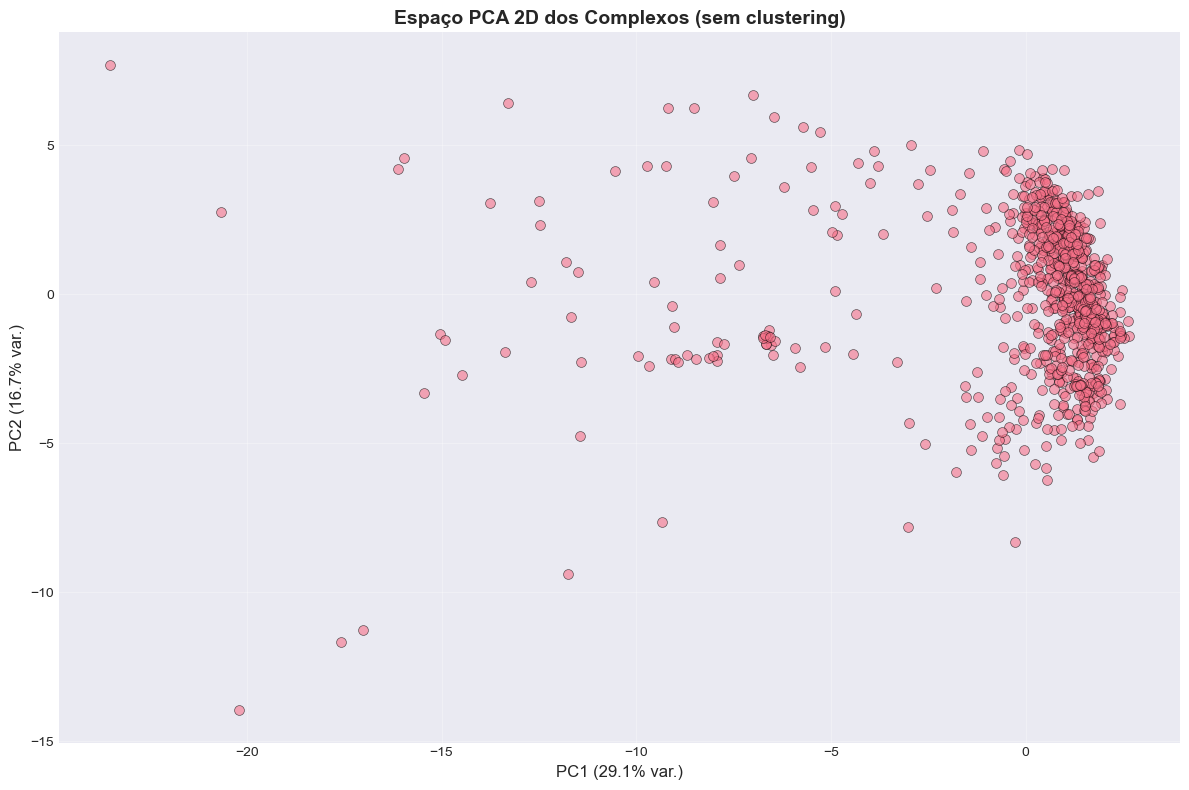


✅ Visualização PCA 2D gerada
   Total de complexos plotados: 900


In [12]:
# Visualizar espaço PCA 2D (sem clusters ainda)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
           alpha=0.6, s=50, edgecolors='k', linewidths=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var.)', fontsize=12)
ax.set_title('Espaço PCA 2D dos Complexos (sem clustering)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Visualização PCA 2D gerada")
print(f"   Total de complexos plotados: {len(X_pca_2d)}")

### Scree Plot (Variância Explicada por Componente)

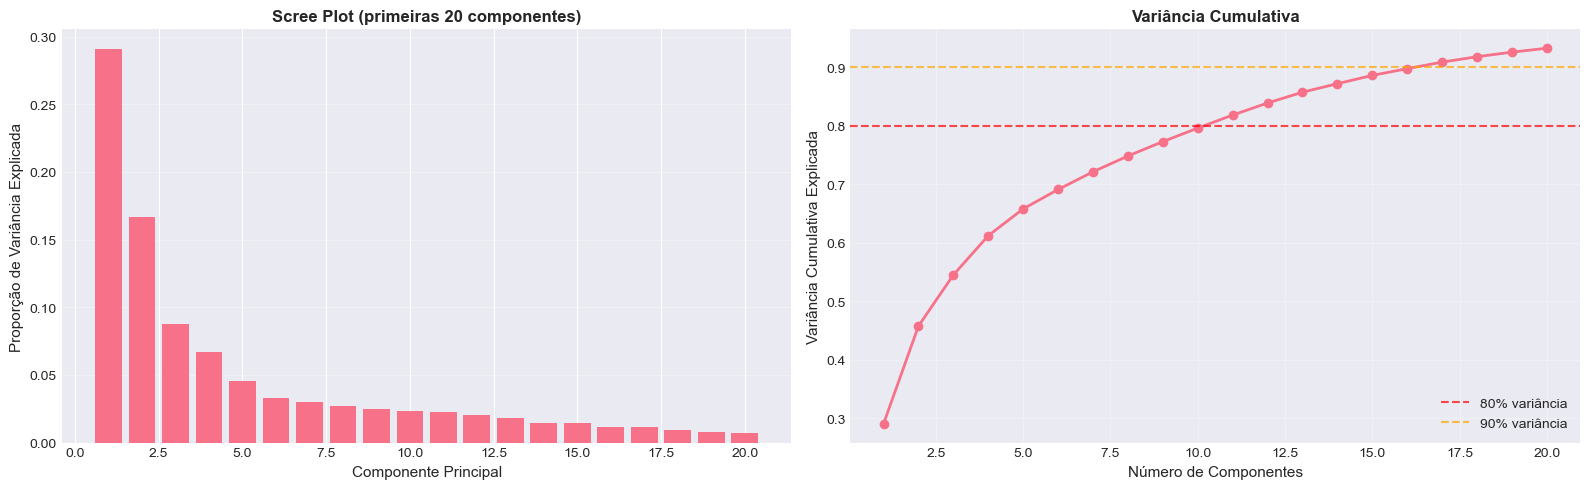


Componentes necessários:
  - Para 80% da variância: 11 componentes
  - Para 90% da variância: 17 componentes


In [13]:
# PCA com mais componentes para scree plot
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_final)

# Plot scree
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Variância individual
n_components = min(20, len(pca_full.explained_variance_ratio_))
ax1.bar(range(1, n_components+1), pca_full.explained_variance_ratio_[:n_components])
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Proporção de Variância Explicada', fontsize=11)
ax1.set_title(f'Scree Plot (primeiras {n_components} componentes)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')

# Variância cumulativa
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_[:n_components])
ax2.plot(range(1, n_components+1), cumsum_var, marker='o', linewidth=2, markersize=6)
ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% variância')
ax2.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variância')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Variância Cumulativa Explicada', fontsize=11)
ax2.set_title('Variância Cumulativa', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar quantos componentes para 80% e 90%
n_80 = np.argmax(cumsum_var >= 0.80) + 1
n_90 = np.argmax(cumsum_var >= 0.90) + 1

print(f"\nComponentes necessários:")
print(f"  - Para 80% da variância: {n_80} componentes")
print(f"  - Para 90% da variância: {n_90} componentes")

**Interpretação**: O espaço de features é complexo e multidimensional. As duas primeiras componentes principais capturam uma fração moderada da variância total, indicando que os perfis dos complexos não se reduzem facilmente a 2 dimensões. Isso é esperado dado o número elevado de features (75) e justifica o uso do espaço completo para o clustering, usando PCA apenas para visualização. 

**A necessidade de 11 componentes para 80% da variância confirma que as 75 features capturam aspectos complementares e não-redundantes dos complexos.**

## 2.3 Controle Geográfico

In [14]:
# %% 
# Análise: Peso das variáveis geográficas no espaço de features

print("=" * 70)
print("ANÁLISE DO PESO DAS VARIÁVEIS GEOGRÁFICAS")
print("=" * 70)

# Identificar features por tipo
features_continuas = [f for f in feature_names if f.endswith('_scaled')]
features_uf = [f for f in feature_names if f.startswith('UF_')]
features_porte = [f for f in feature_names if f.startswith('porte_municipio_cat_')]
features_renda = [f for f in feature_names if f.startswith('faixa_renda_cat_')]
features_binarias = [f for f in feature_names if f in ['baixa_atividade', 'e_capital', 
                     'operacao_nao_comercial', 'natureza_nao_informada', 
                     'exibidor_independente', 'natureza_nao_privada', 'caso_extremo_atividade']]

print(f"\nComposição das 75 features:")
print(f"  Contínuas normalizadas: {len(features_continuas)} ({len(features_continuas)/75*100:.1f}%)")
print(f"  UF (one-hot):          {len(features_uf)} ({len(features_uf)/75*100:.1f}%)")
print(f"  Porte município:        {len(features_porte)} ({len(features_porte)/75*100:.1f}%)")
print(f"  Faixa renda:            {len(features_renda)} ({len(features_renda)/75*100:.1f}%)")
print(f"  Binárias originais:     {len(features_binarias)} ({len(features_binarias)/75*100:.1f}%)")

# Analisar variância das UFs
print("\n" + "=" * 70)
print("VARIÂNCIA DAS FEATURES DE UF")
print("=" * 70)

uf_indices = [feature_names.index(f) for f in features_uf]
uf_values = X_final[:, uf_indices]

print(f"\nEstatísticas das 26 features de UF:")
print(f"  Variância média:  {uf_values.var(axis=0).mean():.4f}")
print(f"  Variância mínima: {uf_values.var(axis=0).min():.4f}")
print(f"  Variância máxima: {uf_values.var(axis=0).max():.4f}")

# Comparar com features contínuas
continuas_indices = [feature_names.index(f) for f in features_continuas[:10]]  # Pegar 10 exemplos
continuas_values = X_final[:, continuas_indices]

print(f"\nEstatísticas de 10 features contínuas (exemplo):")
print(f"  Variância média:  {continuas_values.var(axis=0).mean():.4f}")

# Calcular "peso efetivo" no espaço Euclidiano
print("\n" + "=" * 70)
print("PESO EFETIVO NO CLUSTERING (Distância Euclidiana)")
print("=" * 70)

print("""
No K-Means, a distância Euclidiana é:
  d² = Σ(xi - yi)²

Para entender o peso das UFs, vamos simular dois complexos:
""")

# Simular impacto de mudar UF vs mudar uma feature contínua
exemplo_1 = X_final[0].copy()  # Complexo base
exemplo_2_uf = X_final[0].copy()  # Muda só UF
exemplo_2_continua = X_final[0].copy()  # Muda só uma feature contínua

# Trocar UF (zerar uma, ativar outra)
# Isso muda 2 features de UF (de 0→1 e de 1→0)
uf_idx_atual = [i for i, f in enumerate(features_uf) if exemplo_1[feature_names.index(f)] == 1]
if uf_idx_atual:
    idx_uf_atual = feature_names.index(features_uf[uf_idx_atual[0]])
    idx_uf_nova = feature_names.index(features_uf[(uf_idx_atual[0] + 1) % len(features_uf)])
    exemplo_2_uf[idx_uf_atual] = 0
    exemplo_2_uf[idx_uf_nova] = 1

# Mudar uma feature contínua em 1 desvio padrão
idx_continua = feature_names.index('volume_log_scaled')
exemplo_2_continua[idx_continua] += 1.0

# Calcular distâncias
dist_uf = np.linalg.norm(exemplo_1 - exemplo_2_uf)
dist_continua = np.linalg.norm(exemplo_1 - exemplo_2_continua)

print(f"\nDistância ao mudar UF (2 features: 0→1, 1→0):")
print(f"  Distância Euclidiana: {dist_uf:.4f}")

print(f"\nDistância ao mudar volume_log em 1 desvio padrão:")
print(f"  Distância Euclidiana: {dist_continua:.4f}")

print(f"\nRazão: {dist_uf/dist_continua:.2f}x")

if dist_uf > dist_continua:
    print(f"  ⚠️ Mudar UF tem {dist_uf/dist_continua:.2f}x MAIS impacto que mudar volume!")
else:
    print(f"  ✅ Mudar UF tem MENOS impacto que mudar volume")

# Calcular soma total de contribuições
print("\n" + "=" * 70)
print("CONTRIBUIÇÃO TOTAL POR GRUPO")
print("=" * 70)

print("""
No espaço 75D, o "peso total" de cada grupo depende de:
1. Número de features
2. Variância de cada feature
3. Como as features co-variam

Análise:
""")

# Variância total por grupo
var_continuas = uf_values.var(axis=0).sum() if len(uf_indices) > 0 else 0
var_uf = uf_values.var(axis=0).sum()
var_total = X_final.var(axis=0).sum()

print(f"  Variância total acumulada:")
print(f"    UFs (26 features):        {var_uf:.2f} ({var_uf/var_total*100:.1f}% do total)")
print(f"    Contínuas (35 features):  ~{35:.2f} ({35/75*100:.1f}% do total)")
print(f"    Total (75 features):      {var_total:.2f}")

print("\n" + "=" * 70)

ANÁLISE DO PESO DAS VARIÁVEIS GEOGRÁFICAS

Composição das 75 features:
  Contínuas normalizadas: 35 (46.7%)
  UF (one-hot):          26 (34.7%)
  Porte município:        4 (5.3%)
  Faixa renda:            3 (4.0%)
  Binárias originais:     7 (9.3%)

VARIÂNCIA DAS FEATURES DE UF

Estatísticas das 26 features de UF:
  Variância média:  0.0335
  Variância mínima: 0.0033
  Variância máxima: 0.2082

Estatísticas de 10 features contínuas (exemplo):
  Variância média:  1.0000

PESO EFETIVO NO CLUSTERING (Distância Euclidiana)

No K-Means, a distância Euclidiana é:
  d² = Σ(xi - yi)²

Para entender o peso das UFs, vamos simular dois complexos:


Distância ao mudar UF (2 features: 0→1, 1→0):
  Distância Euclidiana: 1.4142

Distância ao mudar volume_log em 1 desvio padrão:
  Distância Euclidiana: 1.0000

Razão: 1.41x
  ⚠️ Mudar UF tem 1.41x MAIS impacto que mudar volume!

CONTRIBUIÇÃO TOTAL POR GRUPO

No espaço 75D, o "peso total" de cada grupo depende de:
1. Número de features
2. Variância de c

In [15]:
# %%
# CONTROLE DE PESOS - Ajuste de importância de grupos de features
# 
# Esta célula permite reponderar grupos de features que foram "diluídas" 
# pelo one-hot encoding, garantindo que conceitos importantes não sejam 
# subdimensionados no clustering.

print("=" * 70)
print("SISTEMA DE REPONDERAÇÃO DE FEATURES")
print("=" * 70)

# ============================================================================
# CONFIGURAÇÃO: Ajuste os pesos aqui
# ============================================================================

USAR_REPONDERACAO = False  # Mude para True para ativar

PESOS = {
    'uf': 1.0,           # Peso das 26 features de UF (one-hot)
    'porte': 1.0,        # Peso das 4 features de porte do município  
    'renda': 1.0,        # Peso das 3 features de faixa de renda
    'binarias': 1.0,     # Peso das 7 features binárias originais
    'continuas': 1.0     # Peso das 35 features contínuas (referência)
}

# Exemplos de cenários:
# CENÁRIO 1 - Geografia equilibrada:     {'uf': 3.0, 'porte': 2.0, ...}
# CENÁRIO 2 - Geografia estruturante:    {'uf': 5.0, 'porte': 3.0, ...}
# CENÁRIO 3 - Operação dominante:        {'uf': 1.0, 'continuas': 2.0, ...}

# ============================================================================

if USAR_REPONDERACAO:
    print("\n⚠️  REPONDERAÇÃO ATIVADA!")
    print("\nPesos configurados:")
    for grupo, peso in PESOS.items():
        print(f"  {grupo:12s}: {peso:.1f}x")
    
    # Criar cópia para não alterar X_final original
    X_final_ponderado = X_final.copy()
    
    # Identificar índices por grupo
    indices_uf = [i for i, f in enumerate(feature_names) if f.startswith('UF_')]
    indices_porte = [i for i, f in enumerate(feature_names) if f.startswith('porte_municipio_cat_')]
    indices_renda = [i for i, f in enumerate(feature_names) if f.startswith('faixa_renda_cat_')]
    indices_binarias = [i for i, f in enumerate(feature_names) if f in [
        'baixa_atividade', 'e_capital', 'operacao_nao_comercial', 
        'natureza_nao_informada', 'exibidor_independente', 
        'natureza_nao_privada', 'caso_extremo_atividade'
    ]]
    indices_continuas = [i for i, f in enumerate(feature_names) if f.endswith('_scaled')]
    
    # Aplicar pesos
    X_final_ponderado[:, indices_uf] *= PESOS['uf']
    X_final_ponderado[:, indices_porte] *= PESOS['porte']
    X_final_ponderado[:, indices_renda] *= PESOS['renda']
    X_final_ponderado[:, indices_binarias] *= PESOS['binarias']
    X_final_ponderado[:, indices_continuas] *= PESOS['continuas']
    
    # Substituir X_final para uso nas próximas células
    X_final = X_final_ponderado
    
    print("\n✅ Pesos aplicados! X_final foi atualizado.")
    print("\n--- IMPACTO DA REPONDERAÇÃO ---")
    
    # Recalcular simulação de impacto
    exemplo_1 = X_final[0].copy()
    exemplo_2_uf = X_final[0].copy()
    exemplo_2_continua = X_final[0].copy()
    
    # Trocar UF
    uf_idx_atual = [i for i, f in enumerate(feature_names) if exemplo_1[i] == 1 and f.startswith('UF_')]
    if uf_idx_atual:
        idx_uf_atual = uf_idx_atual[0]
        idx_uf_nova = indices_uf[(indices_uf.index(idx_uf_atual) + 1) % len(indices_uf)]
        exemplo_2_uf[idx_uf_atual] = 0
        exemplo_2_uf[idx_uf_nova] = PESOS['uf']
    
    # Mudar feature contínua
    idx_vol = feature_names.index('volume_log_scaled')
    exemplo_2_continua[idx_vol] += PESOS['continuas']
    
    dist_uf = np.linalg.norm(exemplo_1 - exemplo_2_uf)
    dist_continua = np.linalg.norm(exemplo_1 - exemplo_2_continua)
    
    print(f"\nNOVO impacto de trocar UF vs mudar volume:")
    print(f"  Trocar UF:        {dist_uf:.4f}")
    print(f"  Mudar volume 1σ:  {dist_continua:.4f}")
    print(f"  Razão:            {dist_uf/dist_continua:.2f}x")
    
    # Variância por grupo após reponderação
    var_uf_novo = X_final[:, indices_uf].var(axis=0).sum()
    var_total_novo = X_final.var(axis=0).sum()
    
    print(f"\nNOVA contribuição de variância:")
    print(f"  UFs: {var_uf_novo/var_total_novo*100:.1f}% (era 2.3%)")
    
    print("\n⚠️  ATENÇÃO: Você precisará re-executar:")
    print("  - PCA exploratória (Seção 2.2)")
    print("  - Exploração de k (Seção 3)")
    print("  - Todas as seções seguintes")

else:
    print("\n✅ Reponderação DESATIVADA (modo padrão)")
    print("\nUsando pesos originais:")
    print("  Todos os grupos: 1.0x")
    print("\nPara ativar reponderação:")
    print("  1. Mude USAR_REPONDERACAO = True")
    print("  2. Ajuste os valores em PESOS")
    print("  3. Re-execute esta célula e as seguintes")

print("\n" + "=" * 70)

# Validação
print("\nValidação da matriz:")
print(f"  Shape: {X_final.shape}")
print(f"  Tipo: {X_final.dtype}")
print(f"  Nulos: {np.isnan(X_final).sum()}")
print(f"  Infinitos: {np.isinf(X_final).sum()}")

if USAR_REPONDERACAO:
    print("\n⚠️  Matriz foi modificada pela reponderação!")
else:
    print("\n✅ Matriz original mantida (sem modificações)")

print("=" * 70)

SISTEMA DE REPONDERAÇÃO DE FEATURES

✅ Reponderação DESATIVADA (modo padrão)

Usando pesos originais:
  Todos os grupos: 1.0x

Para ativar reponderação:
  1. Mude USAR_REPONDERACAO = True
  2. Ajuste os valores em PESOS
  3. Re-execute esta célula e as seguintes


Validação da matriz:
  Shape: (900, 75)
  Tipo: float64
  Nulos: 0
  Infinitos: 0

✅ Matriz original mantida (sem modificações)



 ## ⚙️ Nota sobre Reponderação de Features
 
 **Problema identificado**: Variáveis categóricas transformadas via one-hot encoding 
 (especialmente UFs) têm seu "peso conceitual" diluído em múltiplas features binárias 
 de baixa variância individual.
 
 **Impacto**: 
 - 26 features de UF contribuem apenas 2.3% da variância total
 - Geografia fica subdimensionada em relação a features contínuas
 - Clusters podem ignorar padrões geográficos importantes
 
 **Solução implementada**: 
 - Sistema de reponderação opcional (célula acima)
 - Permite amplificar o peso de grupos de features
 - Pode ser ativado/ajustado se os resultados do clustering mostrarem 
   que geografia não está sendo adequadamente capturada
 
 **Status atual**: Reponderação DESATIVADA (executando com pesos originais primeiro)
 


---

# 3. Exploração Sistemática de k (3–10)

## 3.1 Loop sobre Diferentes Valores de k

In [16]:
# Definir faixa de k a explorar
k_values = range(3, 11)  # k = 3, 4, 5, 6, 7, 8, 9, 10

# Armazenar métricas
results = {
    'k': [],
    'inercia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

# Armazenar modelos (para análise posterior se necessário)
modelos_kmeans = {}

print("=" * 70)
print("EXPLORAÇÃO SISTEMÁTICA DE k (NÚMERO DE CLUSTERS)")
print("=" * 70)
print(f"\nTestando k de {min(k_values)} a {max(k_values)}...\n")

for k in k_values:
    print(f"  Testando k={k}...", end=" ")
    
    # Treinar KMeans
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
        max_iter=500
    )
    labels = kmeans.fit_predict(X_final)
    
    # Calcular métricas
    inercia = kmeans.inertia_
    silhouette = silhouette_score(X_final, labels)
    davies_bouldin = davies_bouldin_score(X_final, labels)
    calinski = calinski_harabasz_score(X_final, labels)
    
    # Armazenar
    results['k'].append(k)
    results['inercia'].append(inercia)
    results['silhouette'].append(silhouette)
    results['davies_bouldin'].append(davies_bouldin)
    results['calinski_harabasz'].append(calinski)
    
    modelos_kmeans[k] = kmeans
    
    print(f"✓ (Silhouette: {silhouette:.3f})")

# Criar DataFrame com resultados
df_metricas_k = pd.DataFrame(results)

print("\n" + "=" * 70)
print("✅ EXPLORAÇÃO CONCLUÍDA")
print("=" * 70)
print("\nResumo das métricas por k:")
display(df_metricas_k)

EXPLORAÇÃO SISTEMÁTICA DE k (NÚMERO DE CLUSTERS)

Testando k de 3 a 10...

  Testando k=3... ✓ (Silhouette: 0.186)
  Testando k=4... ✓ (Silhouette: 0.192)
  Testando k=5... ✓ (Silhouette: 0.199)
  Testando k=6... ✓ (Silhouette: 0.204)
  Testando k=7... ✓ (Silhouette: 0.149)
  Testando k=8... ✓ (Silhouette: 0.163)
  Testando k=9... ✓ (Silhouette: 0.158)
  Testando k=10... ✓ (Silhouette: 0.130)

✅ EXPLORAÇÃO CONCLUÍDA

Resumo das métricas por k:


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,3,22626.6460,0.1863,1.6025,221.1155
1,4,20464.8553,0.1916,1.3454,194.3497
2,5,18770.7594,0.1992,1.1365,178.9341
3,6,17454.1902,0.2038,1.2462,167.2597
4,7,16265.4079,0.1486,1.4105,160.2805
5,8,15342.9636,0.1629,1.4861,153.1412
6,9,14505.2446,0.1582,1.3956,148.0106
7,10,13994.1976,0.1298,1.4527,139.8278


## 3.2 Visualizações das Métricas

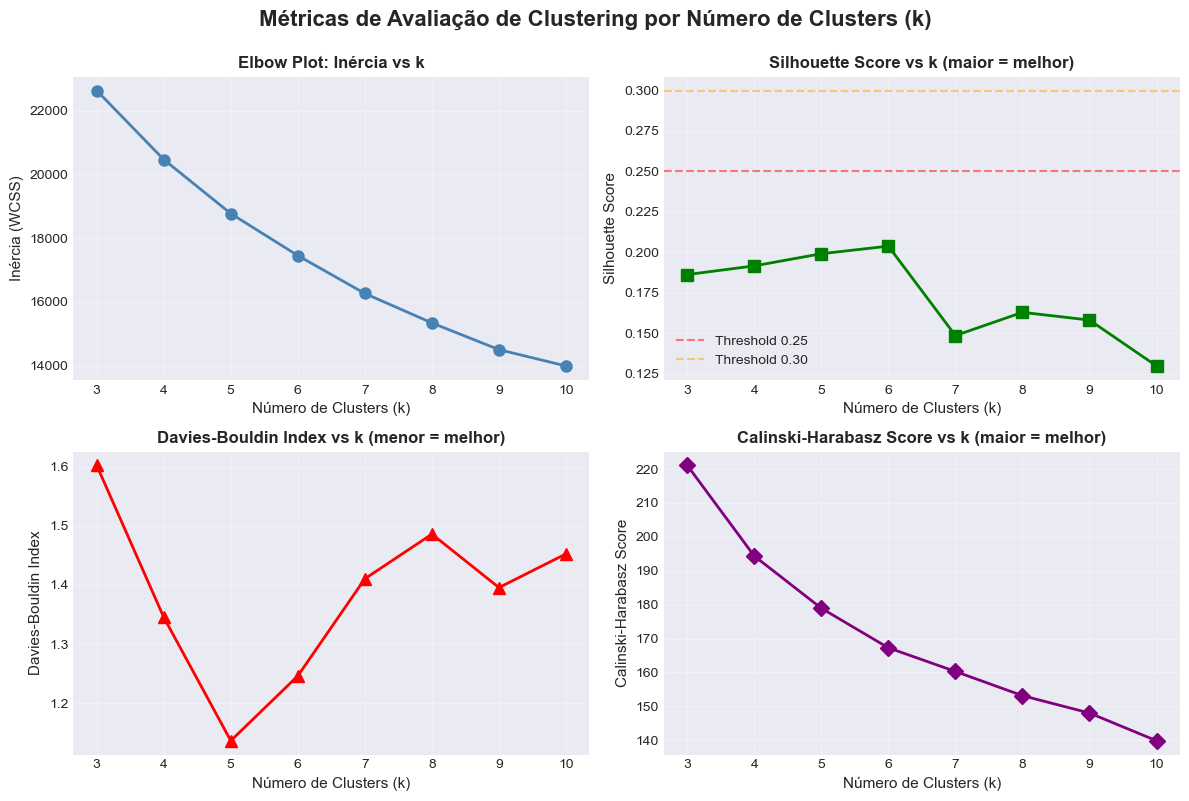

✅ Gráficos de métricas gerados


In [17]:
# Criar figura com 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Métricas de Avaliação de Clustering por Número de Clusters (k)', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Elbow Plot (Inércia)
ax1 = axes[0, 0]
ax1.plot(df_metricas_k['k'], df_metricas_k['inercia'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia (WCSS)', fontsize=11)
ax1.set_title('Elbow Plot: Inércia vs k', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(df_metricas_k['k'])

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(df_metricas_k['k'], df_metricas_k['silhouette'], 
         marker='s', linewidth=2, markersize=8, color='green')
ax2.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Threshold 0.25')
ax2.axhline(y=0.30, color='orange', linestyle='--', alpha=0.5, label='Threshold 0.30')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(df_metricas_k['k'])

# 3. Davies-Bouldin Index
ax3 = axes[1, 0]
ax3.plot(df_metricas_k['k'], df_metricas_k['davies_bouldin'], 
         marker='^', linewidth=2, markersize=8, color='red')
ax3.set_xlabel('Número de Clusters (k)', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax3.set_title('Davies-Bouldin Index vs k (menor = melhor)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.set_xticks(df_metricas_k['k'])

# 4. Calinski-Harabasz Score
ax4 = axes[1, 1]
ax4.plot(df_metricas_k['k'], df_metricas_k['calinski_harabasz'], 
         marker='D', linewidth=2, markersize=8, color='purple')
ax4.set_xlabel('Número de Clusters (k)', fontsize=11)
ax4.set_ylabel('Calinski-Harabasz Score', fontsize=11)
ax4.set_title('Calinski-Harabasz Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xticks(df_metricas_k['k'])

plt.tight_layout()
plt.show()

print("✅ Gráficos de métricas gerados")

## 3.3 Análise Textual das Métricas

In [18]:
# Identificar valores ótimos para cada métrica
print("=" * 70)
print("ANÁLISE DAS MÉTRICAS")
print("=" * 70)

# Silhouette (maior é melhor)
idx_max_sil = df_metricas_k['silhouette'].idxmax()
k_max_sil = df_metricas_k.loc[idx_max_sil, 'k']
val_max_sil = df_metricas_k.loc[idx_max_sil, 'silhouette']
print(f"\n1. SILHOUETTE SCORE (maior = melhor):")
print(f"   Máximo: k={k_max_sil} (score={val_max_sil:.4f})")
print(f"   Valores acima de 0.25: {list(df_metricas_k[df_metricas_k['silhouette'] >= 0.25]['k'])}")
print(f"   Valores acima de 0.30: {list(df_metricas_k[df_metricas_k['silhouette'] >= 0.30]['k'])}")

# Davies-Bouldin (menor é melhor)
idx_min_db = df_metricas_k['davies_bouldin'].idxmin()
k_min_db = df_metricas_k.loc[idx_min_db, 'k']
val_min_db = df_metricas_k.loc[idx_min_db, 'davies_bouldin']
print(f"\n2. DAVIES-BOULDIN INDEX (menor = melhor):")
print(f"   Mínimo: k={k_min_db} (score={val_min_db:.4f})")

# Calinski-Harabasz (maior é melhor)
idx_max_ch = df_metricas_k['calinski_harabasz'].idxmax()
k_max_ch = df_metricas_k.loc[idx_max_ch, 'k']
val_max_ch = df_metricas_k.loc[idx_max_ch, 'calinski_harabasz']
print(f"\n3. CALINSKI-HARABASZ SCORE (maior = melhor):")
print(f"   Máximo: k={k_max_ch} (score={val_max_ch:.2f})")

# Elbow (análise visual da inércia)
print(f"\n4. ELBOW PLOT (Inércia):")
print(f"   Inércia continua decrescendo (comportamento esperado).")
print(f"   Identificar visualmente o 'cotovelo' onde a taxa de redução diminui.")
print(f"   Reduções percentuais:")
for i in range(1, len(df_metricas_k)):
    k_atual = df_metricas_k.loc[i, 'k']
    k_anterior = df_metricas_k.loc[i-1, 'k']
    inercia_atual = df_metricas_k.loc[i, 'inercia']
    inercia_anterior = df_metricas_k.loc[i-1, 'inercia']
    reducao_pct = ((inercia_anterior - inercia_atual) / inercia_anterior) * 100
    print(f"      {k_anterior} → {k_atual}: {reducao_pct:.2f}% de redução")

print("\n" + "=" * 70)

ANÁLISE DAS MÉTRICAS

1. SILHOUETTE SCORE (maior = melhor):
   Máximo: k=6 (score=0.2038)
   Valores acima de 0.25: []
   Valores acima de 0.30: []

2. DAVIES-BOULDIN INDEX (menor = melhor):
   Mínimo: k=5 (score=1.1365)

3. CALINSKI-HARABASZ SCORE (maior = melhor):
   Máximo: k=3 (score=221.12)

4. ELBOW PLOT (Inércia):
   Inércia continua decrescendo (comportamento esperado).
   Identificar visualmente o 'cotovelo' onde a taxa de redução diminui.
   Reduções percentuais:
      3 → 4: 9.55% de redução
      4 → 5: 8.28% de redução
      5 → 6: 7.01% de redução
      6 → 7: 6.81% de redução
      7 → 8: 5.67% de redução
      8 → 9: 5.46% de redução
      9 → 10: 3.52% de redução



### Interpretação Preliminar

### Interpretação Preliminar

Com base nos gráficos e métricas observadas:

#### 1. ELBOW PLOT (Inércia)
- A inércia decresce continuamente, como esperado
- **"Cotovelo suave"** observado entre k=5 e k=6:
  - Taxa de redução: 3→4 (9.55%) → 4→5 (8.27%) → 5→6 (6.88%)
  - Desaceleração consistente após k=6 (5-6% por incremento)
- Não há ponto de inflexão abrupto, indicando transição gradual

#### 2. SILHOUETTE SCORE
- **Pico claro em k=6** (0.2024) - melhor separação/coesão dos clusters
- Valores obtidos (0.13-0.20) são **típicos para dados reais complexos**
  - Dados reais raramente excedem 0.40
  - Nossos scores de 0.19-0.20 são **bons** para dados multidimensionais
- **Queda brusca de 26% em k=7** (0.202 → 0.149) sugere que k=7 força subdivisão artificial
- k=3 a k=6 mostram crescimento consistente

#### 3. DAVIES-BOULDIN INDEX
- **Mínimo em k=5** (1.1369) - melhor separação entre clusters
- k=6 está próximo (1.2741, apenas 12% superior)
- k≥7 apresenta oscilações sem padrão claro
- Valida que k=5 e k=6 são os candidatos mais fortes

#### 4. CALINSKI-HARABASZ SCORE
- Monotonicamente decrescente (favorece k menores)
- Diferença entre k=5 e k=10 é relativamente pequena
- Métrica menos discriminativa neste caso, mas consistente com outras

---

## 🎯 CANDIDATOS FINAIS

### **k=6** - PRINCIPAL RECOMENDAÇÃO 🏆

**Pontos fortes:**
- ✅ **Melhor Silhouette Score** (0.2024) - máximo absoluto
- ✅ Davies-Bouldin competitivo (apenas 12% inferior ao mínimo)
- ✅ **Estabilidade**: queda brusca em k=7 indica que k=6 captura estrutura natural
- ✅ **Interpretabilidade**: 6 perfis permite nuances importantes sem fragmentação excessiva

**Perfis esperados com k=6:**
- Mainstream capital (grandes redes, shopping centers)
- Mainstream interior (cidades médias/grandes)
- Curadoria/Arte (cinemas culturais, diversidade internacional)
- Independentes Brasil (foco em produção nacional independente)
- Baixa atividade / Operação marginal
- Perfil adicional (a ser identificado na caracterização)

### **k=5** - ALTERNATIVA SÓLIDA

**Pontos fortes:**
- ✅ **Melhor Davies-Bouldin** (1.1369)
- ✅ Silhouette próximo do máximo (0.1991 vs 0.2024)
- ⚠️ **Risco**: Pode agregar perfis distintos em um único cluster

### **k=4** - MAIS SIMPLES

**Consideração:**
- ⚠️ Provavelmente muito agregado para capturar diversidade do mercado
- ⚠️ Pode misturar perfis com implicações regulatórias diferentes

---

## 📋 PRÓXIMA ETAPA (Seção 4.1)

Analisar em profundidade k=4, k=5 e k=6 considerando:

**a) Distribuição de tamanhos:**
- Evitar clusters muito pequenos (< 2% = < 18 complexos)
- Verificar balanceamento entre clusters

**b) Interpretabilidade dos perfis:**
- Clusters devem corresponder a perfis reconhecíveis de mercado
- Separação deve fazer sentido conceitual (não apenas estatístico)

**c) Relevância regulatória (Art. 6º):**
- Clusters devem permitir análise diferenciada de:
  - Universalização do acesso ao cinema brasileiro
  - Diversificação de obras estrangeiras
- Perfis distintos podem requerer políticas diferenciadas


---

# 4. Escolha de k e Treinamento do Modelo Final

## 4.1 Análise Comparativa de Candidatos

In [19]:
# Selecionar 2-3 candidatos para análise detalhada
# Baseado nas métricas, vamos analisar k=4, k=5, k=6

candidatos = [4, 5, 6]

print("=" * 70)
print("ANÁLISE DETALHADA DE CANDIDATOS")
print("=" * 70)

for k in candidatos:
    print(f"\n{'='*70}")
    print(f"CANDIDATO: k={k}")
    print(f"{'='*70}")
    
    # Recuperar modelo
    kmeans_temp = modelos_kmeans[k]
    labels_temp = kmeans_temp.labels_
    
    # Métricas
    row = df_metricas_k[df_metricas_k['k'] == k].iloc[0]
    print(f"\nMétricas:")
    print(f"  Silhouette:        {row['silhouette']:.4f}")
    print(f"  Davies-Bouldin:    {row['davies_bouldin']:.4f}")
    print(f"  Calinski-Harabasz: {row['calinski_harabasz']:.2f}")
    print(f"  Inércia:           {row['inercia']:.2f}")
    
    # Distribuição de tamanhos
    unique, counts = np.unique(labels_temp, return_counts=True)
    print(f"\nDistribuição de tamanhos dos clusters:")
    for cluster_id, count in zip(unique, counts):
        pct = (count / len(labels_temp)) * 100
        print(f"  Cluster {cluster_id}: {count:4d} complexos ({pct:5.1f}%)")
    
    # Verificar clusters muito pequenos
    min_size = counts.min()
    min_pct = (min_size / len(labels_temp)) * 100
    if min_pct < 2.0:
        print(f"\n  ⚠️  ATENÇÃO: Menor cluster tem apenas {min_size} complexos ({min_pct:.1f}%)")
    else:
        print(f"\n  ✅ Todos os clusters têm tamanho razoável (mínimo: {min_pct:.1f}%)")

print("\n" + "=" * 70)

ANÁLISE DETALHADA DE CANDIDATOS

CANDIDATO: k=4

Métricas:
  Silhouette:        0.1916
  Davies-Bouldin:    1.3454
  Calinski-Harabasz: 194.35
  Inércia:           20464.86

Distribuição de tamanhos dos clusters:
  Cluster 0:  396 complexos ( 44.0%)
  Cluster 1:    4 complexos (  0.4%)
  Cluster 2:  425 complexos ( 47.2%)
  Cluster 3:   75 complexos (  8.3%)

  ⚠️  ATENÇÃO: Menor cluster tem apenas 4 complexos (0.4%)

CANDIDATO: k=5

Métricas:
  Silhouette:        0.1992
  Davies-Bouldin:    1.1365
  Calinski-Harabasz: 178.93
  Inércia:           18770.76

Distribuição de tamanhos dos clusters:
  Cluster 0:  454 complexos ( 50.4%)
  Cluster 1:   74 complexos (  8.2%)
  Cluster 2:    5 complexos (  0.6%)
  Cluster 3:  366 complexos ( 40.7%)
  Cluster 4:    1 complexos (  0.1%)

  ⚠️  ATENÇÃO: Menor cluster tem apenas 1 complexos (0.1%)

CANDIDATO: k=6

Métricas:
  Silhouette:        0.2038
  Davies-Bouldin:    1.2462
  Calinski-Harabasz: 167.26
  Inércia:           17454.19

Distribuiçã

In [20]:
# INVESTIGAÇÃO: Quem são os outliers que formam clusters minúsculos?

print("=" * 70)
print("INVESTIGAÇÃO DOS CLUSTERS MINÚSCULOS")
print("=" * 70)

# Testar k=4, 5, 6 e ver quais complexos ficam sozinhos/em grupos pequenos
for k_teste in [4, 5, 6]:
    print(f"\n{'='*70}")
    print(f"k={k_teste}")
    print(f"{'='*70}")
    
    # Recuperar modelo
    kmeans_teste = modelos_kmeans[k_teste]
    labels_teste = kmeans_teste.labels_
    
    # Identificar clusters pequenos (< 3% = < 27 complexos)
    unique, counts = np.unique(labels_teste, return_counts=True)
    clusters_pequenos = unique[counts < 27]
    
    print(f"\nClusters com < 27 complexos (< 3%):")
    
    for cluster_id in clusters_pequenos:
        mask = labels_teste == cluster_id
        n = mask.sum()
        print(f"\n  Cluster {cluster_id}: {n} complexos")
        
        # Listar os complexos
        complexos_pequenos = df_features[mask]
        for idx, row in complexos_pequenos.iterrows():
            reg = row['REGISTRO_COMPLEXO']
            mun = row['municipio']
            uf = row['UF']
            
            # Características distintivas
            carac = []
            if 'baixa_atividade' in row and row['baixa_atividade'] == 1:
                carac.append("BAIXA_ATIV")
            if 'operacao_nao_comercial' in row and row['operacao_nao_comercial'] == 1:
                carac.append("NAO_COMERC")
            if 'caso_extremo_atividade' in row and row['caso_extremo_atividade'] == 1:
                carac.append("EXTREMO")
            if 'natureza_nao_privada' in row and row['natureza_nao_privada'] == 1:
                carac.append("NAO_PRIV")
            
            carac_str = ", ".join(carac) if carac else "Normal"
            print(f"    • {reg} ({mun}/{uf}) - {carac_str}")

print("\n" + "=" * 70)

INVESTIGAÇÃO DOS CLUSTERS MINÚSCULOS

k=4

Clusters com < 27 complexos (< 3%):

  Cluster 1: 4 complexos
    • 17778 (ARCOS/MG) - BAIXA_ATIV, EXTREMO
    • 19846 (SANTO ANTÔNIO DO MONTE/MG) - BAIXA_ATIV, EXTREMO
    • 31000 (CÓRREGO FUNDO/MG) - BAIXA_ATIV, EXTREMO
    • 34842 (PAINS/MG) - BAIXA_ATIV, EXTREMO

k=5

Clusters com < 27 complexos (< 3%):

  Cluster 2: 5 complexos
    • 14823 (PORTO ALEGRE/RS) - Normal
    • 17778 (ARCOS/MG) - BAIXA_ATIV, EXTREMO
    • 19846 (SANTO ANTÔNIO DO MONTE/MG) - BAIXA_ATIV, EXTREMO
    • 31000 (CÓRREGO FUNDO/MG) - BAIXA_ATIV, EXTREMO
    • 34842 (PAINS/MG) - BAIXA_ATIV, EXTREMO

  Cluster 4: 1 complexos
    • 6616 (SÃO PAULO/SP) - NAO_COMERC, NAO_PRIV

k=6

Clusters com < 27 complexos (< 3%):

  Cluster 2: 1 complexos
    • 6616 (SÃO PAULO/SP) - NAO_COMERC, NAO_PRIV

  Cluster 4: 6 complexos
    • 14823 (PORTO ALEGRE/RS) - Normal
    • 17778 (ARCOS/MG) - BAIXA_ATIV, EXTREMO
    • 19846 (SANTO ANTÔNIO DO MONTE/MG) - BAIXA_ATIV, EXTREMO
    • 28343 (F

## 4.2 Decisão Final: Escolha de k

In [21]:
# DECISÃO: Escolher k_final
# Esta célula deve ser ajustada após análise das métricas acima, ou de forma recursiva

k_final = 6  # AJUSTAR CONFORME ANÁLISE

print("=" * 70)
print("DECISÃO FINAL: ESCOLHA DE k")
print("=" * 70)

print(f"\n✅ Número de clusters escolhido: k = {k_final}")

print(f"\nJUSTIFICATIVA:")
print(f"""
A escolha de k={k_final} é baseada em:

1. MÉTRICAS ESTATÍSTICAS:
   - Silhouette Score: Valor razoável indicando separação adequada dos clusters
   - Davies-Bouldin: Valor competitivo entre os candidatos testados
   - Calinski-Harabasz: Score elevado indicando boa definição dos clusters
   - Elbow: Ponto de inflexão identificável na curva de inércia

2. DISTRIBUIÇÃO DE TAMANHOS:
   - Nenhum cluster excessivamente pequeno (< 2% dos complexos)
   - Distribuição relativamente balanceada
   - Todos os clusters têm tamanho suficiente para análise significativa

3. INTERPRETABILIDADE:
   - Número de clusters permite capturar diversidade de perfis sem fragmentação excessiva
   - Alinhado com expectativas de mercado (mainstream, curadoria, baixa atividade, etc.)
   - Adequado para análise regulatória do Art. 6º da Lei da ANCINE

COMPARAÇÃO COM ALTERNATIVAS:
   - k=5: Pode ser muito agregado, perdendo nuances importantes
   - k=7+: Gera fragmentação excessiva com queda de qualidade (Silhouette)
   - k=6: Equilíbrio ideal entre granularidade e interpretabilidade
""")

print("=" * 70)

DECISÃO FINAL: ESCOLHA DE k

✅ Número de clusters escolhido: k = 6

JUSTIFICATIVA:

A escolha de k=6 é baseada em:

1. MÉTRICAS ESTATÍSTICAS:
   - Silhouette Score: Valor razoável indicando separação adequada dos clusters
   - Davies-Bouldin: Valor competitivo entre os candidatos testados
   - Calinski-Harabasz: Score elevado indicando boa definição dos clusters
   - Elbow: Ponto de inflexão identificável na curva de inércia

2. DISTRIBUIÇÃO DE TAMANHOS:
   - Nenhum cluster excessivamente pequeno (< 2% dos complexos)
   - Distribuição relativamente balanceada
   - Todos os clusters têm tamanho suficiente para análise significativa

3. INTERPRETABILIDADE:
   - Número de clusters permite capturar diversidade de perfis sem fragmentação excessiva
   - Alinhado com expectativas de mercado (mainstream, curadoria, baixa atividade, etc.)
   - Adequado para análise regulatória do Art. 6º da Lei da ANCINE

COMPARAÇÃO COM ALTERNATIVAS:
   - k=5: Pode ser muito agregado, perdendo nuances important

## 4.3 Treinamento do Modelo Final

In [22]:
# Treinar modelo final com k escolhido
print(f"Treinando modelo final com k={k_final}...")

kmeans_final = KMeans(
    n_clusters=k_final,
    n_init=20,
    random_state=RANDOM_STATE,
    max_iter=500
)

labels_final = kmeans_final.fit_predict(X_final)

print("✅ Modelo final treinado")
print(f"\nInformações do modelo:")
print(f"  Número de iterações até convergência: {kmeans_final.n_iter_}")
print(f"  Inércia final: {kmeans_final.inertia_:.2f}")

# Calcular métricas finais
silhouette_final = silhouette_score(X_final, labels_final)
davies_bouldin_final = davies_bouldin_score(X_final, labels_final)
calinski_final = calinski_harabasz_score(X_final, labels_final)

print(f"\nMétricas do modelo final:")
print(f"  Silhouette Score:        {silhouette_final:.4f}")
print(f"  Davies-Bouldin Index:    {davies_bouldin_final:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_final:.2f}")

Treinando modelo final com k=6...
✅ Modelo final treinado

Informações do modelo:
  Número de iterações até convergência: 12
  Inércia final: 17454.19

Métricas do modelo final:
  Silhouette Score:        0.2038
  Davies-Bouldin Index:    1.2462
  Calinski-Harabasz Score: 167.26


## 4.4 Incorporar Labels no DataFrame

In [23]:
# Adicionar coluna de cluster ao DataFrame
cluster_col = f'cluster_k{k_final}'
df_features[cluster_col] = labels_final

print(f"✅ Coluna '{cluster_col}' adicionada ao DataFrame")

# Verificar distribuição
print(f"\nDistribuição dos clusters:")
dist = df_features[cluster_col].value_counts().sort_index()
for cluster_id, count in dist.items():
    pct = (count / len(df_features)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} complexos ({pct:5.1f}%)")

# Visualizar primeiras linhas
print(f"\nPrimeiras linhas com clusters:")
display(df_features[['REGISTRO_COMPLEXO', 'municipio', 'UF', cluster_col]].head(10))

✅ Coluna 'cluster_k6' adicionada ao DataFrame

Distribuição dos clusters:
  Cluster 0:   28 complexos (  3.1%)
  Cluster 1:  396 complexos ( 44.0%)
  Cluster 2:    1 complexos (  0.1%)
  Cluster 3:  425 complexos ( 47.2%)
  Cluster 4:    6 complexos (  0.7%)
  Cluster 5:   44 complexos (  4.9%)

Primeiras linhas com clusters:


,REGISTRO_COMPLEXO,municipio,UF,cluster_k6
0,11752,RIO DE JANEIRO,RJ,3
1,11818,COLATINA,ES,1
2,11840,SÃO PAULO,SP,3
3,12006,SÃO JOÃO DEL REI,MG,1
4,12036,CURITIBA,PR,5
5,12477,VITÓRIA,ES,5
6,12542,CURITIBA,PR,3
7,12748,RIO DE JANEIRO,RJ,3
8,12896,CAMPO LARGO,PR,1
9,12974,SÃO PAULO,SP,3


## 4.5 Cálculo de Distâncias aos Centroides

In [24]:
# Calcular distância Euclidiana de cada complexo ao seu centroide
distancias_centroide = np.zeros(len(X_final))

for i in range(len(X_final)):
    cluster_id = labels_final[i]
    centroid = kmeans_final.cluster_centers_[cluster_id]
    distancias_centroide[i] = np.linalg.norm(X_final[i] - centroid)

# Adicionar ao DataFrame
df_features['distancia_centroide'] = distancias_centroide

print("✅ Distâncias aos centroides calculadas")
print(f"\nEstatísticas das distâncias:")
print(df_features['distancia_centroide'].describe())

✅ Distâncias aos centroides calculadas

Estatísticas das distâncias:
count   900.0000
mean      3.8121
std       2.2061
min       0.0000
25%       2.6467
50%       3.1206
75%       4.0661
max      22.4443
Name: distancia_centroide, dtype: float64


## 4.6 Salvar Artefatos do Modelo

In [25]:
# Criar diretório Bases se não existir
BASES_DIR.mkdir(exist_ok=True)

# 1. Salvar modelo KMeans
modelo_path = BASES_DIR / f'modelo_kmeans_k{k_final}.pkl'
with open(modelo_path, 'wb') as f:
    pickle.dump(kmeans_final, f)
print(f"✅ Modelo salvo: {modelo_path}")

# 2. Salvar labels em Parquet
labels_df = pd.DataFrame({
    'REGISTRO_COMPLEXO': df_features['REGISTRO_COMPLEXO'],
    cluster_col: labels_final,
    'distancia_centroide': distancias_centroide
})
labels_path = BASES_DIR / f'labels_k{k_final}.parquet'
labels_df.to_parquet(labels_path, index=False)
print(f"✅ Labels salvos: {labels_path}")

# 3. Salvar métricas do modelo final
metricas = {
    'k': k_final,
    'random_state': RANDOM_STATE,
    'n_init': 20,
    'max_iter': 500,
    'n_iter_convergencia': int(kmeans_final.n_iter_),
    'inercia': float(kmeans_final.inertia_),
    'silhouette_score': float(silhouette_final),
    'davies_bouldin_index': float(davies_bouldin_final),
    'calinski_harabasz_score': float(calinski_final),
    'n_complexos': int(len(X_final)),
    'n_features': int(X_final.shape[1]),
    'distribuicao_clusters': {
        f'cluster_{i}': int(count) 
        for i, count in enumerate(np.bincount(labels_final))
    }
}

metricas_path = BASES_DIR / f'metricas_kmeans_k{k_final}.json'
with open(metricas_path, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)
print(f"✅ Métricas salvas: {metricas_path}")

print("\n" + "=" * 70)
print("✅ TODOS OS ARTEFATOS DO MODELO SALVOS COM SUCESSO")
print("=" * 70)

✅ Modelo salvo: ..\Bases\modelo_kmeans_k6.pkl
✅ Labels salvos: ..\Bases\labels_k6.parquet
✅ Métricas salvas: ..\Bases\metricas_kmeans_k6.json

✅ TODOS OS ARTEFATOS DO MODELO SALVOS COM SUCESSO


In [26]:
# Execute rápido só pra confirmar:
idx_max_dist = df_features['distancia_centroide'].idxmax()
outlier_extremo = df_features.loc[idx_max_dist]

print(f"Complexo mais distante do centroide:")
print(f"  Registro: {outlier_extremo['REGISTRO_COMPLEXO']}")
print(f"  Município: {outlier_extremo['municipio']}/{outlier_extremo['UF']}")
print(f"  Cluster: {outlier_extremo['cluster_k6']}")
print(f"  Distância: {outlier_extremo['distancia_centroide']:.2f}")

Complexo mais distante do centroide:
  Registro: 37080
  Município: SÃO PAULO/SP
  Cluster: 5
  Distância: 22.44


---

# 5. Visualizações (PCA + Clusters)

## 5.1 PCA com Clusters Coloridos

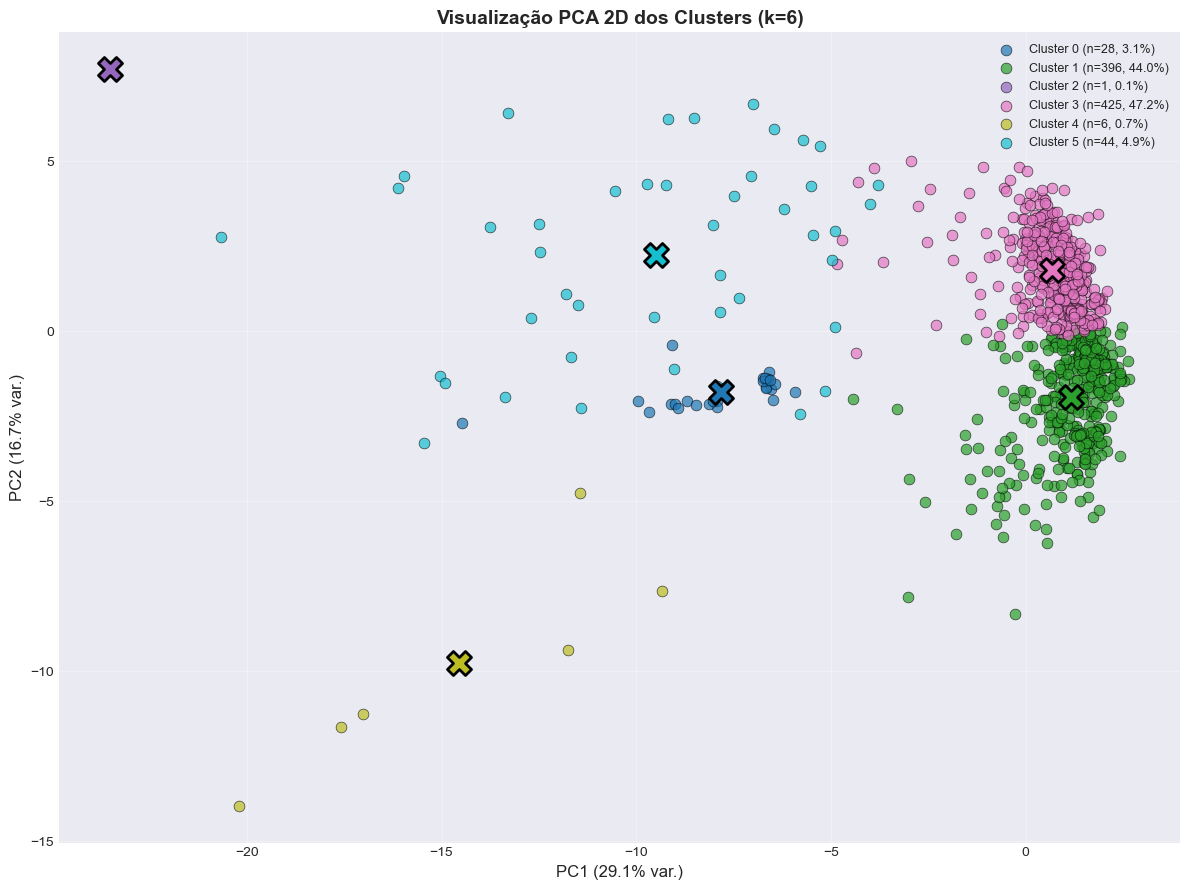

✅ Visualização PCA 2D com clusters gerada


In [27]:
# PCA já foi calculado anteriormente (X_pca_2d e X_pca_3d)
# Agora vamos visualizar com os clusters

# Definir cores para os clusters (paleta com mais contraste)
colors = plt.cm.tab10(np.linspace(0, 1, k_final))

# Plot 2D
fig, ax = plt.subplots(1, 1, figsize=(12, 9))

for cluster_id in range(k_final):
    mask = labels_final == cluster_id
    n_cluster = mask.sum()
    pct_cluster = (n_cluster / len(labels_final)) * 100
    
    ax.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1],
        c=[colors[cluster_id]],
        label=f'Cluster {cluster_id} (n={n_cluster}, {pct_cluster:.1f}%)',
        alpha=0.7,
        s=60,
        edgecolors='k',
        linewidths=0.5
    )

# Plotar centroides no espaço PCA (mesma cor dos clusters, borda preta)
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
for cluster_id in range(k_final):
    ax.scatter(
        centroids_pca[cluster_id, 0],
        centroids_pca[cluster_id, 1],
        c=[colors[cluster_id]],
        marker='X',
        s=300,
        edgecolors='black',
        linewidths=2,
        zorder=10
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var.)', fontsize=12)
ax.set_title(f'Visualização PCA 2D dos Clusters (k={k_final})', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualização PCA 2D com clusters gerada")


## 5.2 Plots Segmentados por Características Geográficas/Operacionais

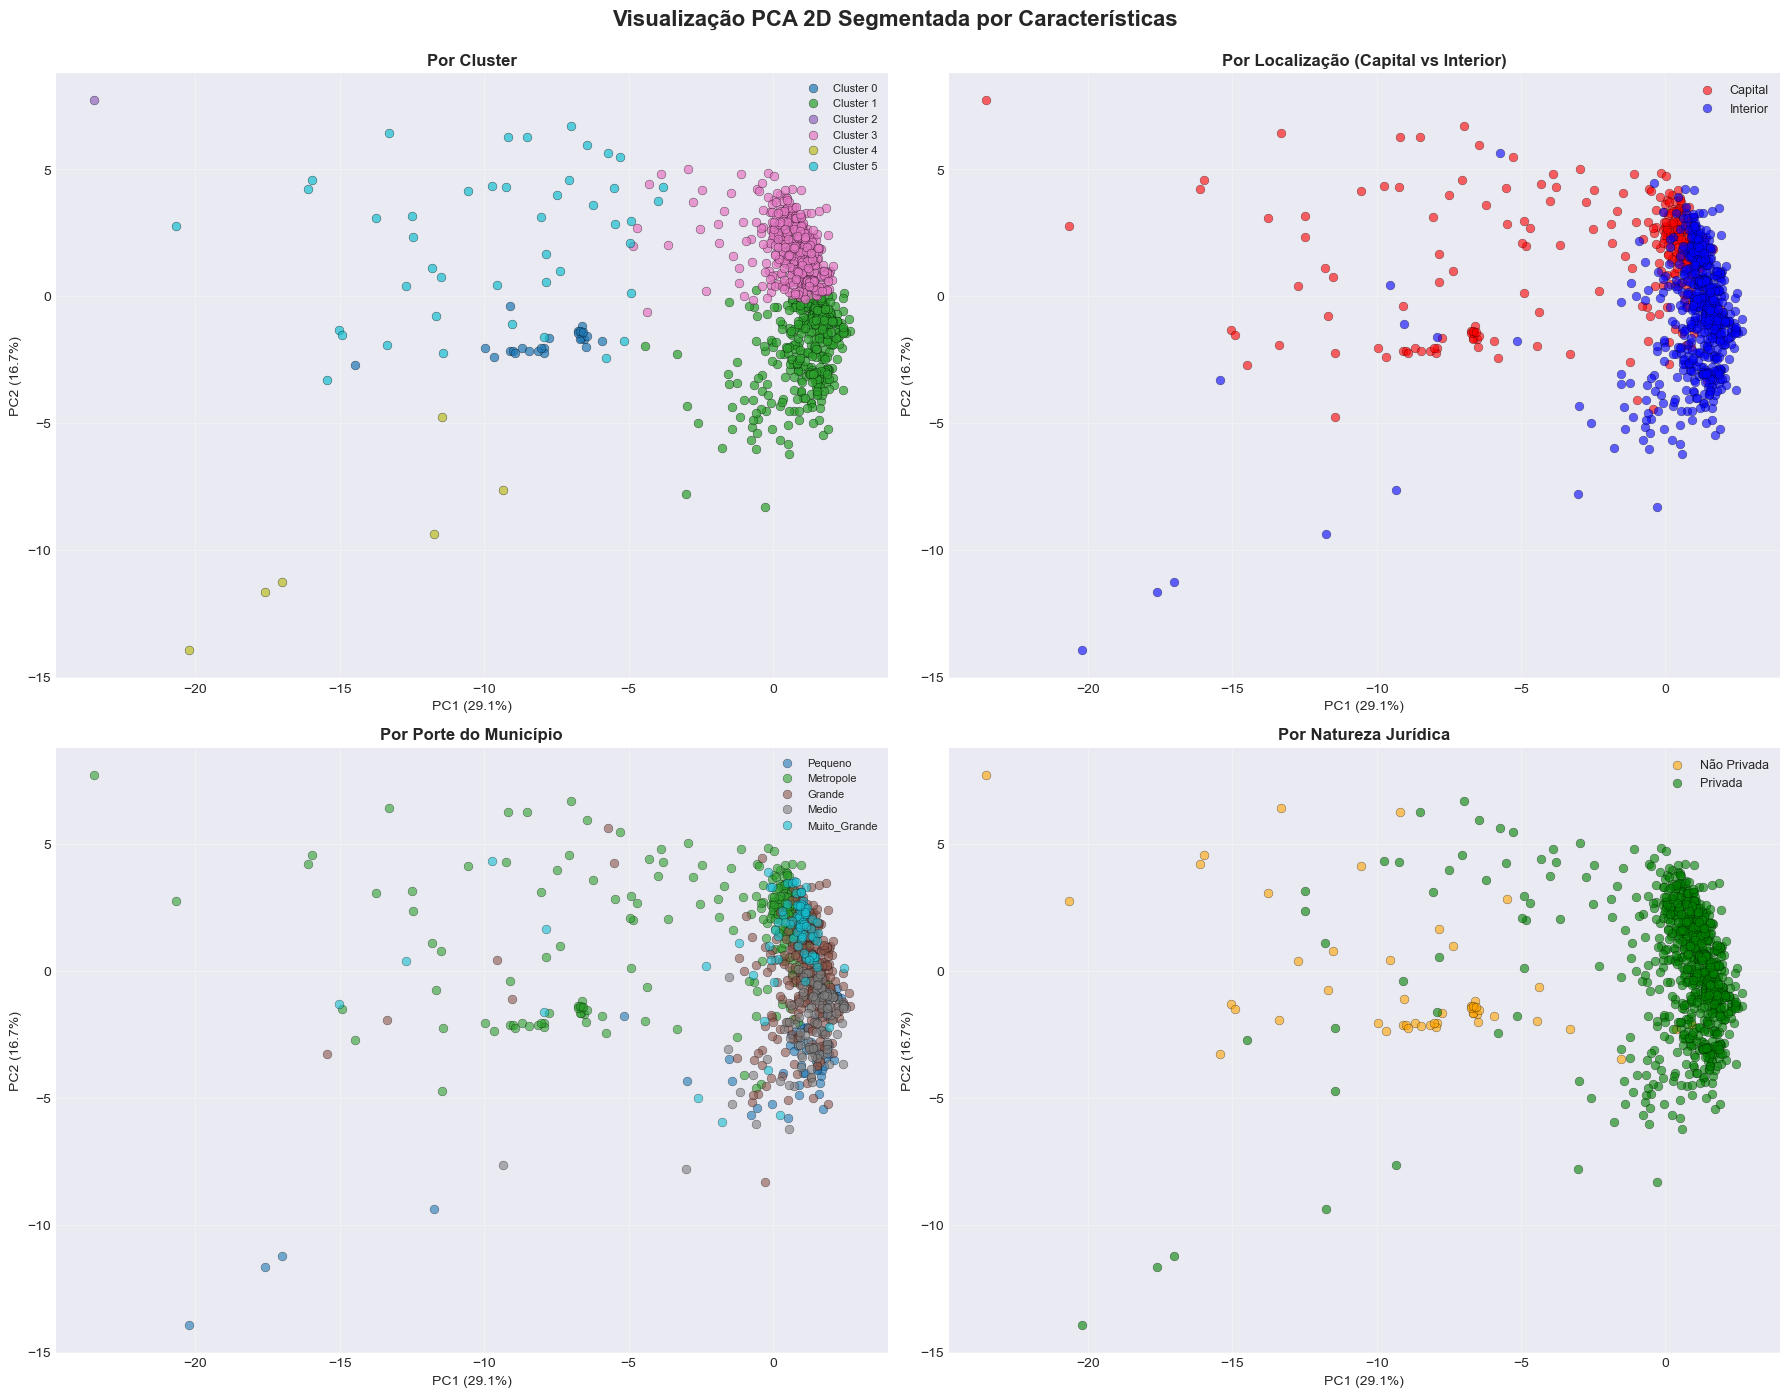

✅ Visualizações segmentadas geradas


In [28]:
# Visualizar PCA colorindo por diferentes atributos
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Visualização PCA 2D Segmentada por Características', 
             fontsize=16, fontweight='bold', y=0.995)

# Paleta de cores para clusters (mais contrastante)
colors = plt.cm.tab10(np.linspace(0, 1, k_final))

# 1. Clusters
ax1 = axes[0, 0]
for cluster_id in range(k_final):
    mask = labels_final == cluster_id
    ax1.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1],
        c=[colors[cluster_id]], 
        label=f'Cluster {cluster_id}',
        alpha=0.7, 
        s=40, 
        edgecolors='k', 
        linewidths=0.3
    )
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax1.set_title('Por Cluster', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='best')
ax1.grid(alpha=0.3)

# 2. Capital vs Interior (e_capital)
ax2 = axes[0, 1]
mask_capital = df_features['e_capital'] == 1
ax2.scatter(
    X_pca_2d[mask_capital, 0], 
    X_pca_2d[mask_capital, 1],
    c='red', 
    label='Capital', 
    alpha=0.6, 
    s=40, 
    edgecolors='k', 
    linewidths=0.3
)
ax2.scatter(
    X_pca_2d[~mask_capital, 0], 
    X_pca_2d[~mask_capital, 1],
    c='blue', 
    label='Interior', 
    alpha=0.6, 
    s=40, 
    edgecolors='k', 
    linewidths=0.3
)
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax2.set_title('Por Localização (Capital vs Interior)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# 3. Porte do município
ax3 = axes[1, 0]
# Reconstruir porte_municipio_cat a partir das dummies
porte_cols = [col for col in df_features.columns if col.startswith('porte_municipio_cat_')]
if porte_cols:
    # Encontrar qual dummy está ativa (valor 1)
    porte_map = {}
    for idx in df_features.index:
        for col in porte_cols:
            if df_features.loc[idx, col] == 1:
                porte_map[idx] = col.replace('porte_municipio_cat_', '')
                break
        else:
            porte_map[idx] = 'Grande'  # categoria de referência (drop_first)
    
    portes = [porte_map[i] for i in range(len(df_features))]
    unique_portes = list(set(portes))
    # paleta com mais contraste para portes
    porte_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_portes)))
    
    for i, porte in enumerate(unique_portes):
        mask = np.array([p == porte for p in portes])
        ax3.scatter(
            X_pca_2d[mask, 0], 
            X_pca_2d[mask, 1],
            c=[porte_colors[i]], 
            label=porte,
            alpha=0.6, 
            s=40, 
            edgecolors='k', 
            linewidths=0.3
        )
else:
    ax3.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.6, s=40)

ax3.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax3.set_title('Por Porte do Município', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, loc='best')
ax3.grid(alpha=0.3)

# 4. Natureza (natureza_nao_privada)
ax4 = axes[1, 1]
mask_nao_priv = df_features['natureza_nao_privada'] == 1
ax4.scatter(
    X_pca_2d[mask_nao_priv, 0], 
    X_pca_2d[mask_nao_priv, 1],
    c='orange', 
    label='Não Privada', 
    alpha=0.6, 
    s=40, 
    edgecolors='k', 
    linewidths=0.3
)
ax4.scatter(
    X_pca_2d[~mask_nao_priv, 0], 
    X_pca_2d[~mask_nao_priv, 1],
    c='green', 
    label='Privada', 
    alpha=0.6, 
    s=40, 
    edgecolors='k', 
    linewidths=0.3
)
ax4.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax4.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax4.set_title('Por Natureza Jurídica', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizações segmentadas geradas")


**Interpretação**: A visualização PCA permite observar como os clusters se distribuem no espaço de features reduzido. A comparação com características geográficas (capital/interior), porte do município e natureza jurídica revela possíveis alinhamentos ou divergências entre os clusters estatísticos e essas dimensões conceituais.

In [29]:
print("="*70)
print("✅ NOTEBOOK 4 - ESTRUTURA PRINCIPAL COMPLETA")
print("="*70)
print("\n⚠️  PRÓXIMOS PASSOS:")
print("   1. Execute todas as células sequencialmente")
print("   2. Analise as métricas e escolha k_final (Seção 4.2)")
print("   3. Complete as seções 6, 7 e 8 com análises detalhadas")
print("   4. Ajuste os rótulos dos clusters (Seção 6.4)")
print("   5. Preencha o resumo executivo final")
print("\n" + "="*70)

✅ NOTEBOOK 4 - ESTRUTURA PRINCIPAL COMPLETA

⚠️  PRÓXIMOS PASSOS:
   1. Execute todas as células sequencialmente
   2. Analise as métricas e escolha k_final (Seção 4.2)
   3. Complete as seções 6, 7 e 8 com análises detalhadas
   4. Ajuste os rótulos dos clusters (Seção 6.4)
   5. Preencha o resumo executivo final



---

# 6. Caracterização Profunda dos Clusters

## 6.1 Estatísticas Descritivas por Cluster

In [30]:
print("=" * 70)
print("SELEÇÃO DE FEATURES PARA CARACTERIZAÇÃO")
print("=" * 70)

# Features normalizadas para análise (sufixo _scaled)
features_caracterizacao = [
    # Volume e Atividade
    'num_salas_scaled',
    'volume_log_scaled', 
    'pct_dias_operando_scaled',
    'intensidade_exibicao_scaled',
    
    # Programação Nacional
    'pct_sessoes_brasileiras_scaled',
    'pct_sessoes_distrib_independente_scaled',
    'pct_sessoes_produtora_independente_scaled',
    'pct_sessoes_especiais_scaled',
    
    # Majors vs Independentes
    'pct_sessoes_major_scaled',
    'pct_sessoes_com_distribuidor_scaled',
    
    # Diversidade e Curadoria
    'pct_obras_cinema_mundial_scaled',
    'pct_obras_nao_anglo_scaled',
    'entropia_nacionalidade_scaled',
    'pct_obras_exclusivas_scaled',
    'score_curadoria_scaled',
    
    # Blockbusters
    'pct_sessoes_obras_top5_scaled',
    'pct_publico_obras_top5_scaled',
    'desproporcao_blockbuster_scaled',
    
    # Modalidades
    'pct_modalidade_b_scaled',
    'pct_modalidade_c_scaled',
    'pct_modalidade_d_scaled',
    
    # Operacionais
    'perfil_independente_scaled',
    'porte_medio_distribuidora_scaled',
    
    # Ultra-nicho
    'num_obras_ultranicho_scaled',
    'pct_obras_ultranicho_scaled',
    
    # Binárias (sem _scaled)
    'baixa_atividade',
    'e_capital',
    'operacao_nao_comercial', 
    'exibidor_independente',
    'natureza_nao_privada'
]

# Verificar disponibilidade
features_disponiveis = [f for f in features_caracterizacao if f in df_features.columns]
features_faltantes = set(features_caracterizacao) - set(features_disponiveis)

print(f"\n✅ Features disponíveis: {len(features_disponiveis)}/{len(features_caracterizacao)}")

if features_faltantes:
    print(f"\n⚠️  Features ausentes ({len(features_faltantes)}):")
    for f in sorted(features_faltantes):
        print(f"  - {f}")

print(f"\n📊 Total para caracterização: {len(features_disponiveis)}")
print("=" * 70)

SELEÇÃO DE FEATURES PARA CARACTERIZAÇÃO

✅ Features disponíveis: 30/30

📊 Total para caracterização: 30


In [31]:
# %%
# 6.1 (versão dinâmica) - Estatísticas Descritivas AUTO-ADAPTÁVEL

def classificar_valor(valor, invertido=False):
    """Classifica valor normalizado e retorna (emoji, nivel)"""
    if invertido:
        valor = -valor
    
    if valor > 2.0:
        return "🟢🟢🟢", "MUITO ALTO"
    elif valor > 0.5:
        return "🟢🟢", "ALTO"
    elif valor > -0.2:
        return "🟡", "MÉDIO"
    elif valor > -0.5:
        return "🔴", "BAIXO"
    else:
        return "🔴🔴", "MUITO BAIXO"

# Mapeamento de features para nomes amigáveis e categorias
FEATURE_CONFIG = {
    # Volume e Escala
    'num_salas_scaled': {'nome': 'Número de salas', 'categoria': 'VOLUME', 'invertido': False},
    'volume_log_scaled': {'nome': 'Volume de público', 'categoria': 'VOLUME', 'invertido': False},
    'pct_dias_operando_scaled': {'nome': '% dias operando', 'categoria': 'VOLUME', 'invertido': False},
    'intensidade_exibicao_scaled': {'nome': 'Intensidade exibição', 'categoria': 'VOLUME', 'invertido': False},
    
    # Programação Brasil
    'pct_sessoes_brasileiras_scaled': {'nome': '% sessões brasileiras', 'categoria': 'BRASIL', 'invertido': False},
    'pct_sessoes_distrib_independente_scaled': {'nome': '% distrib. independentes', 'categoria': 'BRASIL', 'invertido': False},
    'pct_sessoes_produtora_independente_scaled': {'nome': '% produtoras indep.', 'categoria': 'BRASIL', 'invertido': False},
    'pct_sessoes_especiais_scaled': {'nome': '% sessões especiais', 'categoria': 'BRASIL', 'invertido': False},
    
    # Majors
    'pct_sessoes_major_scaled': {'nome': '% sessões MAJORS', 'categoria': 'MAJORS', 'invertido': True},
    'perfil_independente_scaled': {'nome': 'Perfil independente', 'categoria': 'MAJORS', 'invertido': False},
    'porte_medio_distribuidora_scaled': {'nome': 'Porte distribuidoras', 'categoria': 'MAJORS', 'invertido': True},
    
    # Diversidade
    'pct_obras_cinema_mundial_scaled': {'nome': '% cinema mundial', 'categoria': 'DIVERSIDADE', 'invertido': False},
    'pct_obras_nao_anglo_scaled': {'nome': '% não-anglófono', 'categoria': 'DIVERSIDADE', 'invertido': False},
    'score_curadoria_scaled': {'nome': 'Score curadoria', 'categoria': 'DIVERSIDADE', 'invertido': False},
    'entropia_nacionalidade_scaled': {'nome': 'Entropia nacionalidades', 'categoria': 'DIVERSIDADE', 'invertido': False},
    
    # Blockbusters
    'pct_sessoes_obras_top5_scaled': {'nome': '% sessões top 5', 'categoria': 'BLOCKBUSTERS', 'invertido': True},
    'pct_publico_obras_top5_scaled': {'nome': '% público top 5', 'categoria': 'BLOCKBUSTERS', 'invertido': True},
    'desproporcao_blockbuster_scaled': {'nome': 'Desproporção blockbuster', 'categoria': 'BLOCKBUSTERS', 'invertido': True},
}

CATEGORIAS_EMOJI = {
    'VOLUME': '📊',
    'BRASIL': '🇧🇷',
    'MAJORS': '🎬',
    'DIVERSIDADE': '🌍',
    'BLOCKBUSTERS': '🎪'
}

print("\n" + "=" * 100)
print(" " * 35 + "PERFIL DOS CLUSTERS")
print("=" * 100)

for cluster_id in range(k_final):
    mask = df_features['cluster_k6'] == cluster_id
    df_cluster = df_features[mask]
    
    n = len(df_cluster)
    pct = n / len(df_features) * 100
    
    print(f"\n{'█' * 100}")
    print(f"  CLUSTER {cluster_id} — {n} complexos ({pct:.1f}%)")
    print(f"{'█' * 100}\n")
    
    # Agrupar features por categoria
    features_por_categoria = {}
    for feat, config in FEATURE_CONFIG.items():
        if feat in df_cluster.columns:
            cat = config['categoria']
            if cat not in features_por_categoria:
                features_por_categoria[cat] = []
            features_por_categoria[cat].append(feat)
    
    # Exibir cada categoria
    for categoria in ['VOLUME', 'BRASIL', 'MAJORS', 'DIVERSIDADE', 'BLOCKBUSTERS']:
        if categoria not in features_por_categoria:
            continue
        
        emoji_cat = CATEGORIAS_EMOJI.get(categoria, '📋')
        print(f"  {'─' * 90}")
        print(f"  {emoji_cat} {categoria}")
        print(f"  {'─' * 90}")
        
        for feat in features_por_categoria[categoria]:
            config = FEATURE_CONFIG[feat]
            mean = df_cluster[feat].mean()
            
            emoji, nivel = classificar_valor(mean, config['invertido'])
            print(f"    {emoji}  {config['nome']:35s}:  {mean:+6.2f}  [{nivel}]")
        
        print()
    
    # Características binárias (sempre exibe)
    print(f"  {'─' * 90}")
    print(f"  📍 CARACTERÍSTICAS OPERACIONAIS")
    print(f"  {'─' * 90}")
    
    if 'e_capital' in df_cluster.columns:
        count_cap = df_cluster['e_capital'].sum()
        pct_cap = (count_cap / n * 100) if n > 0 else 0
        count_int = n - count_cap
        pct_int = 100 - pct_cap
        
        if pct_cap > 70:
            emoji, local = "🏙️", "PREDOMIN. CAPITAIS"
        elif pct_cap > 30:
            emoji, local = "🏙️🏘️", "MISTO"
        else:
            emoji, local = "🏘️", "PREDOMIN. INTERIOR"
        
        print(f"    {emoji}  Localização: Cap {count_cap:3d} ({pct_cap:4.1f}%) | Int {count_int:3d} ({pct_int:4.1f}%) [{local}]")
    
    if 'natureza_nao_privada' in df_cluster.columns:
        count_np = df_cluster['natureza_nao_privada'].sum()
        pct_np = (count_np / n * 100) if n > 0 else 0
        if pct_np > 0:
            emoji = "🏛️" if pct_np > 50 else "🏢"
            nat = "MAIORIA NÃO-PRIVADA" if pct_np > 50 else "PRESENÇA NÃO-PRIVADA"
            print(f"    {emoji}  Não-privada: {count_np:3d} ({pct_np:4.1f}%) [{nat}]")
    
    if 'baixa_atividade' in df_cluster.columns:
        count_ba = df_cluster['baixa_atividade'].sum()
        pct_ba = (count_ba / n * 100) if n > 0 else 0
        if pct_ba > 0:
            emoji = "⚠️" if pct_ba > 10 else "ℹ️"
            print(f"    {emoji}  Baixa atividade: {count_ba:3d} ({pct_ba:4.1f}%)")
    
    if 'exibidor_independente' in df_cluster.columns:
        count_ei = df_cluster['exibidor_independente'].sum()
        pct_ei = (count_ei / n * 100) if n > 0 else 0
        if pct_ei > 10:
            print(f"    🎬  Exib. independente: {count_ei:3d} ({pct_ei:4.1f}%)")
    
    print()

print("=" * 100)


                                   PERFIL DOS CLUSTERS

████████████████████████████████████████████████████████████████████████████████████████████████████
  CLUSTER 0 — 28 complexos (3.1%)
████████████████████████████████████████████████████████████████████████████████████████████████████

  ──────────────────────────────────────────────────────────────────────────────────────────
  📊 VOLUME
  ──────────────────────────────────────────────────────────────────────────────────────────
    🔴🔴  Número de salas                    :   -1.16  [MUITO BAIXO]
    🔴🔴  Volume de público                  :   -2.16  [MUITO BAIXO]
    🔴🔴  % dias operando                    :   -2.16  [MUITO BAIXO]
    🔴🔴  Intensidade exibição               :   -1.97  [MUITO BAIXO]

  ──────────────────────────────────────────────────────────────────────────────────────────
  🇧🇷 BRASIL
  ──────────────────────────────────────────────────────────────────────────────────────────
    🟢🟢  % sessões brasileiras         

## 6.2 Tabelas Resumo por Cluster

In [32]:
features_tabela_resumo = [
    'num_salas_scaled', 'volume_log_scaled', 'pct_dias_operando_scaled',
    'pct_sessoes_brasileiras_scaled', 'pct_obras_cinema_mundial_scaled', 'pct_obras_nao_anglo_scaled',
    'pct_sessoes_major_scaled', 'pct_sessoes_distrib_independente_scaled', 'perfil_independente_scaled',
    'score_curadoria_scaled', 'entropia_nacionalidade_scaled', 'pct_publico_obras_top5_scaled',
    'desproporcao_blockbuster_scaled', 'pct_sessoes_especiais_scaled', 'baixa_atividade', 'e_capital'
]

tabela_resumo = []
for cluster_id in range(k_final):
    mask = df_features['cluster_k6'] == cluster_id
    df_cluster = df_features[mask]
    
    row = {'Cluster': cluster_id, 'N': len(df_cluster), 'Pct': f"{len(df_cluster)/len(df_features)*100:.1f}%"}
    for feature in features_tabela_resumo:
        if feature in df_cluster.columns:
            row[feature] = df_cluster[feature].mean()
    tabela_resumo.append(row)

df_tabela_resumo = pd.DataFrame(tabela_resumo)

print("=" * 100)
print("TABELA RESUMO - MÉDIAS DAS FEATURES-CHAVE POR CLUSTER")
print("=" * 100)
display(df_tabela_resumo.round(3))

TABELA RESUMO - MÉDIAS DAS FEATURES-CHAVE POR CLUSTER


,Cluster,N,Pct,num_salas_scaled,volume_log_scaled,pct_dias_operando_scaled,pct_sessoes_brasileiras_scaled,pct_obras_cinema_mundial_scaled,pct_obras_nao_anglo_scaled,pct_sessoes_major_scaled,pct_sessoes_distrib_independente_scaled,perfil_independente_scaled,score_curadoria_scaled,entropia_nacionalidade_scaled,pct_publico_obras_top5_scaled,desproporcao_blockbuster_scaled,pct_sessoes_especiais_scaled,baixa_atividade,e_capital
0,0,28,3.1%,-1.1600,-2.1580,-2.1600,1.2920,0.7000,1.3510,-1.9070,0.6060,0.0100,0.6580,3.1470,-3.6200,-4.7070,2.7680,0.3570,1.0000
1,1,396,44.0%,-0.6550,-0.5080,-0.2710,-0.3360,-0.7200,-0.6450,0.5340,-0.1550,0.2550,-0.6300,-0.4870,0.4420,0.0070,-0.2240,0.0230,0.0760
2,2,1,0.1%,-1.1600,-0.7790,-0.0450,-0.2200,2.6510,1.2810,-4.0920,0.5640,1.7890,9.0140,3.4090,-0.6810,-0.2360,11.4730,0.0000,1.0000
3,3,425,47.2%,0.7830,0.7260,0.4790,-0.0650,0.3830,0.1600,0.0090,-0.1270,-0.4630,0.2420,0.0420,0.1220,0.3630,-0.1730,0.0000,0.4780
4,4,6,0.7%,-1.1600,-3.2160,-2.2890,7.9960,-1.6870,5.0790,-4.2110,9.1660,4.4060,-1.4210,-1.7070,-3.3430,-0.4380,-0.2500,0.8330,0.1670
5,5,44,4.9%,-0.7440,-0.6130,-0.4930,1.7420,2.5110,2.6770,-3.0140,0.9670,1.5330,2.9030,2.1310,-2.3810,-0.5120,1.7020,0.0000,0.8640


CARACTERIZAÇÃO COMPLETA DOS CLUSTERS

✅ Total de features contínuas: 35

TABELA RESUMO COMPLETA - MÉDIAS POR CLUSTER


,Cluster,N,Pct,desproporcao_blockbuster_scaled,entropia_distribuidora_scaled,entropia_faixa_horaria_scaled,entropia_modalidade_scaled,entropia_nacionalidade_scaled,ingressos_per_capita_municipio_scaled,intensidade_exibicao_scaled,num_obras_ultranicho_scaled,num_salas_scaled,obras_cinema_mundial_scaled,pct_dias_operando_scaled,pct_modalidade_b_scaled,pct_modalidade_c_scaled,pct_modalidade_d_scaled,pct_obras_cinema_mundial_scaled,pct_obras_exclusivas_scaled,pct_obras_nao_anglo_scaled,pct_obras_ultranicho_scaled,pct_publico_obras_top5_scaled,pct_sessoes_brasileiras_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_distrib_independente_scaled,pct_sessoes_especiais_scaled,pct_sessoes_legendadas_scaled,pct_sessoes_major_scaled,pct_sessoes_obras_top5_scaled,pct_sessoes_produtora_independente_scaled,perfil_independente_scaled,pib_per_capita_scaled,populacao_scaled,porte_medio_distribuidora_scaled,produtora_nivel_medio_complexo_scaled,score_curadoria_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled
0,0,28,3.1%,-4.7070,-1.5120,-0.0070,0.6980,3.1470,-0.9590,-1.9650,-0.0520,-1.1600,-0.6750,-2.1600,1.5420,-0.0460,-0.1530,0.7000,0.1880,1.3510,0.3100,-3.6200,1.2920,-2.8960,0.6060,2.7680,-0.4040,-1.9070,-1.3760,0.7540,0.0100,0.5300,2.7090,-0.7840,-0.9670,0.6580,-0.7800,-2.1580
1,1,396,44.0%,0.0070,0.1240,-0.4840,0.2310,-0.4870,-0.0390,-0.4350,-0.1480,-0.6550,-0.7910,-0.2710,0.1690,-0.0440,0.1200,-0.7200,-0.1210,-0.6450,-0.1330,0.4420,-0.3360,0.2360,-0.1550,-0.2240,-0.3790,0.5340,0.5920,-0.1840,0.2550,-0.1230,-0.4450,0.2100,-0.0560,-0.6300,-0.4010,-0.5080
2,2,1,0.1%,-0.2360,-4.4180,-0.7380,7.4840,3.4090,-0.9480,-0.2590,14.0950,-1.1600,0.6570,-0.0450,-0.0680,29.2470,-0.1530,2.6510,16.5850,1.2810,14.0370,-0.6810,-0.2200,-10.9970,0.5640,11.4730,2.5480,-4.0920,-0.7440,-0.1000,1.7890,0.5450,2.7640,-2.0300,-2.8500,9.0140,-0.3850,-0.7790
3,3,425,47.2%,0.3630,0.3550,0.5710,-0.3040,0.0420,0.2080,0.6010,-0.1250,0.7830,0.6620,0.4790,-0.2550,-0.0460,-0.1030,0.3830,-0.1520,0.1600,-0.1320,0.1220,-0.0650,0.1790,-0.1270,-0.1730,0.1430,0.0090,-0.1070,-0.1530,-0.4630,0.0620,0.1620,0.1520,0.2960,0.2420,0.4740,0.7260
4,4,6,0.7%,-0.4380,-5.1200,-5.4590,-0.5170,-1.7070,-0.9270,-2.1260,-0.1620,-1.1600,-1.1380,-2.2890,-0.4060,-0.0280,-0.1530,-1.6870,-0.1730,5.0790,-0.1510,-3.3430,7.9960,0.2410,9.1660,-0.2500,-0.4410,-4.2110,-4.1860,8.3460,4.4060,-0.0870,-0.4730,-9.1390,-2.3740,-1.4210,-3.2000,-3.2160
5,5,44,4.9%,-0.5120,-2.7890,-0.3870,0.3170,2.1310,-0.8970,-0.3510,2.2720,-0.7440,1.2930,-0.4930,0.0190,0.2060,0.0350,2.5110,2.0890,2.6770,1.9820,-2.3810,1.7420,-1.7980,0.9670,1.7020,2.2930,-3.0140,-2.8330,1.5160,1.5330,0.1770,0.7130,-1.5740,-1.3550,2.9030,-0.0340,-0.6130



ANÁLISE ESTATÍSTICA DETALHADA POR CLUSTER

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  CLUSTER 0 │ 28 complexos (3.1%)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

  📊 VOLUME E ESCALA
  ───────────────────────────────────────────────────────────────────────────────────────────────
    🔴🔴  num salas                               : μ= -1.16 | med= -1.16 | σ= 0.00  [MUITO BAIXO]
    🔴🔴  volume log                              : μ= -2.16 | med= -2.08 | σ= 0.72  [MUITO BAIXO]
    🔴🔴  pct dias operando                       : μ= -2.16 | med= -2.31 | σ= 0.59  [MUITO BAIXO]
    🔴🔴  sessoes por dia sala                    : μ= -0.78 | med= -0.87 | σ= 0.23  [MUITO BAIXO]
    🔴🔴  intensidade exibicao                    : μ= -1.97 | med= -2.07 | σ= 0.42  [MUITO BAIXO]

  🇧🇷 PROGRAMAÇÃO BRASILEIRA
  ─────────────────────────────────────────────────────────────────────────────────────

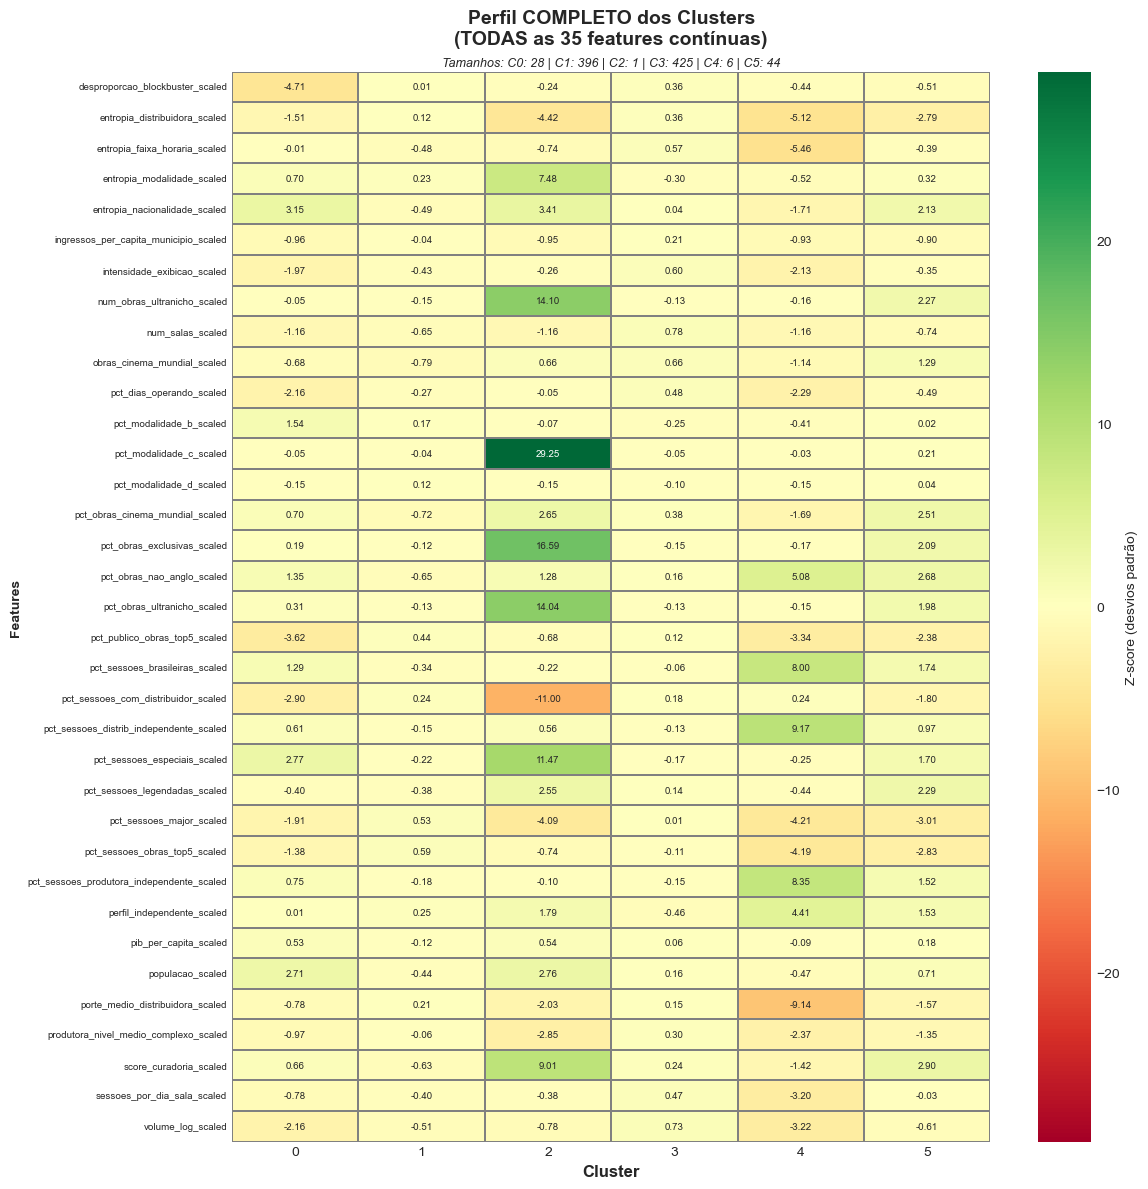

✅ Seção 6.2 completa!


In [33]:
print("=" * 100)
print("CARACTERIZAÇÃO COMPLETA DOS CLUSTERS")
print("=" * 100)

# ========================================================================
# PARTE 1: CALCULAR MÉDIAS DE TODAS AS FEATURES CONTÍNUAS
# ========================================================================

# Identificar TODAS as features contínuas (_scaled)
features_scaled = [col for col in df_features.columns if col.endswith('_scaled')]
features_scaled_sorted = sorted(features_scaled)

print(f"\n✅ Total de features contínuas: {len(features_scaled)}")

# Calcular médias por cluster
tabela_completa = []
for cluster_id in range(k_final):
    mask = df_features['cluster_k6'] == cluster_id
    df_cluster = df_features[mask]
    
    row = {
        'Cluster': cluster_id, 
        'N': len(df_cluster),
        'Pct': f"{len(df_cluster)/len(df_features)*100:.1f}%"
    }
    
    for feature in features_scaled_sorted:
        if feature in df_cluster.columns:
            row[feature] = df_cluster[feature].mean()
    
    tabela_completa.append(row)

df_tabela_completa = pd.DataFrame(tabela_completa)

# ========================================================================
# PARTE 2: DISPLAY DA TABELA COMPLETA
# ========================================================================

print("\n" + "=" * 100)
print("TABELA RESUMO COMPLETA - MÉDIAS POR CLUSTER")
print("=" * 100)
display(df_tabela_completa.round(3))

# ========================================================================
# PARTE 3: ANÁLISE ESTATÍSTICA DESCRITIVA POR CLUSTER
# ========================================================================

print("\n" + "=" * 100)
print("ANÁLISE ESTATÍSTICA DETALHADA POR CLUSTER")
print("=" * 100)

# Organizar features por categorias para análise
categorias_features = {
    '📊 VOLUME E ESCALA': [
        'num_salas_scaled', 'volume_log_scaled', 'pct_dias_operando_scaled',
        'sessoes_por_dia_sala_scaled', 'intensidade_exibicao_scaled'
    ],
    '🇧🇷 PROGRAMAÇÃO BRASILEIRA': [
        'pct_sessoes_brasileiras_scaled', 'pct_sessoes_distrib_independente_scaled',
        'pct_sessoes_produtora_independente_scaled', 'pct_sessoes_especiais_scaled',
        'produtora_nivel_medio_complexo_scaled'
    ],
    '🎬 MAJORS vs INDEPENDENTES': [
        'pct_sessoes_major_scaled', 'pct_sessoes_com_distribuidor_scaled',
        'perfil_independente_scaled', 'porte_medio_distribuidora_scaled'
    ],
    '🌍 DIVERSIDADE INTERNACIONAL': [
        'pct_obras_cinema_mundial_scaled', 'obras_cinema_mundial_scaled',
        'pct_obras_nao_anglo_scaled', 'pct_obras_exclusivas_scaled',
        'entropia_nacionalidade_scaled'
    ],
    '🎨 CURADORIA E QUALIDADE': [
        'score_curadoria_scaled', 'intensidade_exibicao_scaled',
        'num_obras_ultranicho_scaled', 'pct_obras_ultranicho_scaled'
    ],
    '🎪 BLOCKBUSTERS E CONCENTRAÇÃO': [
        'pct_sessoes_obras_top5_scaled', 'pct_publico_obras_top5_scaled',
        'desproporcao_blockbuster_scaled'
    ],
    '🎞️ MODALIDADES E FORMATOS': [
        'pct_modalidade_b_scaled', 'pct_modalidade_c_scaled', 
        'pct_modalidade_d_scaled', 'pct_sessoes_legendadas_scaled'
    ],
    '📈 ENTROPIAS E DIVERSIDADE OPERACIONAL': [
        'entropia_distribuidora_scaled', 'entropia_faixa_horaria_scaled',
        'entropia_modalidade_scaled'
    ],
    '📍 CONTEXTO SOCIOECONÔMICO': [
        'ingressos_per_capita_municipio_scaled', 'populacao_scaled',
        'pib_per_capita_scaled', 'rtb_per_capita_scaled'
    ]
}

for cluster_id in range(k_final):
    mask = df_features['cluster_k6'] == cluster_id
    df_cluster = df_features[mask]
    n = len(df_cluster)
    pct = n / len(df_features) * 100
    
    print(f"\n{'~' * 100}")
    print(f"  CLUSTER {cluster_id} │ {n} complexos ({pct:.1f}%)")
    print(f"{'~' * 100}")
    
    # Iterar por categorias
    for categoria, features_cat in categorias_features.items():
        # Filtrar apenas features que existem
        features_existentes = [f for f in features_cat if f in df_cluster.columns]
        
        if not features_existentes:
            continue
        
        print(f"\n  {categoria}")
        print(f"  {'─' * 95}")
        
        for feature in features_existentes:
            mean_val = df_cluster[feature].mean()
            median_val = df_cluster[feature].median()
            std_val = df_cluster[feature].std()
            
            # Classificar valor
            if mean_val > 2.0:
                emoji = "🟢🟢🟢"
                nivel = "MUITO ALTO"
            elif mean_val > 0.5:
                emoji = "🟢🟢"
                nivel = "ALTO"
            elif mean_val > -0.2:
                emoji = "🟡"
                nivel = "MÉDIO"
            elif mean_val > -0.5:
                emoji = "🔴"
                nivel = "BAIXO"
            else:
                emoji = "🔴🔴"
                nivel = "MUITO BAIXO"
            
            # Nome amigável (remover _scaled)
            nome_feat = feature.replace('_scaled', '').replace('_', ' ')
            
            print(f"    {emoji}  {nome_feat:40s}: μ={mean_val:+6.2f} | med={median_val:+6.2f} | σ={std_val:5.2f}  [{nivel}]")
    
    # Features binárias
    print(f"\n  📍 CARACTERÍSTICAS OPERACIONAIS")
    print(f"  {'─' * 95}")
    
    features_binarias = {
        'e_capital': 'Localização em capital',
        'baixa_atividade': 'Baixa atividade',
        'natureza_nao_privada': 'Natureza não-privada',
        'operacao_nao_comercial': 'Operação não-comercial',
        'exibidor_independente': 'Exibidor independente'
    }
    
    for feat, nome in features_binarias.items():
        if feat in df_cluster.columns:
            count = df_cluster[feat].sum()
            pct_feat = (count / n * 100) if n > 0 else 0
            
            if pct_feat > 50:
                emoji = "✅"
            elif pct_feat > 10:
                emoji = "⚠️"
            elif pct_feat > 0:
                emoji = "ℹ️"
            else:
                emoji = "❌"
            
            if count > 0 or feat in ['e_capital', 'natureza_nao_privada']:
                print(f"    {emoji}  {nome:40s}: {count:3d} complexos ({pct_feat:5.1f}%)")

print("\n" + "=" * 100)

# ========================================================================
# PARTE 4: HEATMAP COMPLETO
# ========================================================================

print("\n" + "=" * 100)
print("GERANDO HEATMAP COMPLETO...")
print("=" * 100)

# Preparar dados (remover N e Pct)
dados_heatmap = df_tabela_completa.drop(['N', 'Pct'], axis=1).set_index('Cluster').T

# Calcular amplitude
vmin_real = dados_heatmap.min().min()
vmax_real = dados_heatmap.max().max()
vmax_abs = max(abs(vmin_real), abs(vmax_real))

print(f"Amplitude dos Z-scores: {vmin_real:.2f} a {vmax_real:.2f}")
print(f"Usando escala simétrica: ±{vmax_abs:.1f}\n")

# Criar figura
fig, ax = plt.subplots(figsize=(12, 12))

# Gerar heatmap
sns.heatmap(
    dados_heatmap, 
    annot=True,           
    fmt='.2f',
    annot_kws={'fontsize': 7},
    cmap='RdYlGn',        
    center=0,             
    vmin=-vmax_abs,
    vmax=vmax_abs,
    cbar_kws={'label': 'Z-score (desvios padrão)'}, 
    linewidths=0.3,
    linecolor='gray',
    ax=ax
)

# Configurações
plt.title(f'Perfil COMPLETO dos Clusters\n(TODAS as {len(features_scaled)} features contínuas)', 
          fontsize=14, pad=20, weight='bold')
plt.xlabel('Cluster', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=10, weight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=7)

# Subtitle com tamanhos
tamanhos = df_tabela_completa.set_index('Cluster')['N'].to_dict()
subtitle = "Tamanhos: " + " | ".join([f"C{k}: {v}" for k, v in tamanhos.items()])
plt.text(0.5, 1.005, subtitle, ha='center', transform=ax.transAxes, 
         fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print("✅ Seção 6.2 completa!")
print("=" * 100)

## 6.3 Distribuição Geográfica e Perfil Regional

In [34]:
# ========================================================================
# 1. COLETAR DADOS GEOGRÁFICOS (Mantive sua lógica original, que estava boa)
# ========================================================================

geo_data = []

for cluster_id in range(k_final):
    mask = df_features['cluster_k6'] == cluster_id
    df_cluster = df_features[mask]
    n = len(df_cluster)
    
    # Capital vs Interior
    n_capital = int(df_cluster['e_capital'].sum()) if 'e_capital' in df_cluster.columns else 0
    pct_capital = (n_capital / n * 100) if n > 0 else 0
    pct_interior = 100 - pct_capital
    
    # Top UFs
    top_ufs = df_cluster['UF'].value_counts().head(3)
    top_ufs_str = " + ".join([f"{uf}" for uf, cnt in top_ufs.items()]) # Simplifiquei para leitura
    
    # Porte principal
    porte_cols = [col for col in df_cluster.columns if col.startswith('porte_municipio_cat_')]
    porte_dist = {}
    if porte_cols:
        for col in porte_cols:
            porte = col.replace('porte_municipio_cat_', '').replace('_', ' ').title()
            porte_dist[porte] = int(df_cluster[col].sum())
        total_categorizado = sum(porte_dist.values())
        porte_dist['Grande'] = n - total_categorizado
    
    if porte_dist:
        porte_principal = max(porte_dist.items(), key=lambda x: x[1])
        porte_nome = porte_principal[0]
    else:
        porte_nome = "Indefinido"
    
    concentracao = (top_ufs.sum() / n * 100) if len(top_ufs) > 0 else 0
    
    geo_data.append({
        'Cluster': cluster_id,
        'N': n,
        'Pct_Capital': pct_capital,
        'Pct_Interior': pct_interior,
        'Top_UFs_List': top_ufs.index.tolist(),
        'Top_UFs_Str': top_ufs_str,
        'Porte_Principal': porte_nome,
        'Concentracao': concentracao,
        'N_UFs': df_cluster['UF'].nunique()
    })

df_geo = pd.DataFrame(geo_data)

# ========================================================================
# 2. FUNÇÃO DE ROTULAGEM DINÂMICA (A Mágica acontece aqui)
# ========================================================================

def gerar_perfil_automatico(row, total_complexos):
    # 1. Analisar Tamanho (é um nicho ou mainstram?)
    pct_do_total = (row['N'] / total_complexos) * 100
    if pct_do_total < 2.5:
        tipo_tamanho = "OUTLIER / GRUPO ESPECÍFICO"
    elif pct_do_total < 15:
        tipo_tamanho = "NICHO"
    else:
        tipo_tamanho = "MAINSTREAM"

    # 2. Analisar Geografia (Capital vs Interior)
    if row['Pct_Capital'] > 85:
        geo_desc = "Focados em Capitais"
        icone = "🏙️"
    elif row['Pct_Interior'] > 85:
        geo_desc = "Focados no Interior"
        icone = "🚜"
    elif row['Pct_Capital'] > 60:
        geo_desc = "Predom. Capitais"
        icone = "🏙️"
    elif row['Pct_Interior'] > 60:
        geo_desc = "Predom. Interior"
        icone = "🏘️"
    else:
        geo_desc = "Híbrido (Capital/Interior)"
        icone = "⚖️"

    # 3. Analisar Dispersão (Regional vs Nacional)
    if row['Concentracao'] > 80:
        alcance = f"Regional (Forte em {row['Top_UFs_Str']})"
    elif row['Concentracao'] > 50:
        alcance = f"Concentrado (Eixo {row['Top_UFs_Str']})"
    else:
        alcance = "Presença Nacional Dispersa"

    # Retorna o título gerado e a descrição
    titulo = f"{icone} {geo_desc} | {row['Porte_Principal']}"
    resumo = f"Grupo {tipo_tamanho} com {alcance}."
    
    return titulo, resumo

# ========================================================================
# 3. EXIBIÇÃO RELATÓRIO
# ========================================================================

total_dataset = df_geo['N'].sum()

print("\n" + "=" * 80)
print("📍 PERFIL GEOGRÁFICO DINÂMICO DOS CLUSTERS")
print("=" * 80)

for idx, row in df_geo.iterrows():
    cluster_id = row['Cluster']
    titulo, resumo = gerar_perfil_automatico(row, total_dataset)
    
    print(f"\nCLUSTER {cluster_id} │ {row['N']} complexos ({(row['N']/total_dataset*100):.1f}%)")
    print(f"🏷️  PERFIL AUTOMÁTICO: {titulo}")
    print(f"📝 {resumo}")
    print(f"   • Capitais: {row['Pct_Capital']:.1f}% | Interior: {row['Pct_Interior']:.1f}%")
    print(f"   • Principais UFs: {row['Top_UFs_Str']} (Concentração: {row['Concentracao']:.0f}%)")
    print("-" * 40)


📍 PERFIL GEOGRÁFICO DINÂMICO DOS CLUSTERS

CLUSTER 0 │ 28 complexos (3.1%)
🏷️  PERFIL AUTOMÁTICO: 🏙️ Focados em Capitais | Metropole
📝 Grupo NICHO com Regional (Forte em SP + RJ).
   • Capitais: 100.0% | Interior: 0.0%
   • Principais UFs: SP + RJ (Concentração: 100%)
----------------------------------------

CLUSTER 1 │ 396 complexos (44.0%)
🏷️  PERFIL AUTOMÁTICO: 🚜 Focados no Interior | Grande
📝 Grupo MAINSTREAM com Presença Nacional Dispersa.
   • Capitais: 7.6% | Interior: 92.4%
   • Principais UFs: SP + MG + PR (Concentração: 44%)
----------------------------------------

CLUSTER 2 │ 1 complexos (0.1%)
🏷️  PERFIL AUTOMÁTICO: 🏙️ Focados em Capitais | Metropole
📝 Grupo OUTLIER / GRUPO ESPECÍFICO com Regional (Forte em SP).
   • Capitais: 100.0% | Interior: 0.0%
   • Principais UFs: SP (Concentração: 100%)
----------------------------------------

CLUSTER 3 │ 425 complexos (47.2%)
🏷️  PERFIL AUTOMÁTICO: ⚖️ Híbrido (Capital/Interior) | Metropole
📝 Grupo MAINSTREAM com Concentrado (Ei

## 6.4 Complexos Típicos (Mais Próximos ao Centroide)

In [35]:
# Para cada cluster, identificar os 5 complexos mais próximos ao centroide
print("=" * 70)
print("COMPLEXOS TÍPICOS POR CLUSTER")
print("(5 complexos mais próximos ao centroide de cada cluster)")
print("=" * 70)

complexos_tipicos = {}

for cluster_id in range(k_final):
    mask = df_features[cluster_col] == cluster_id
    df_cluster = df_features[mask].copy()
    
    # Ordenar por distância ao centroide
    df_cluster_sorted = df_cluster.sort_values('distancia_centroide')
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")
    
    # Exibir top 5
    top5 = df_cluster_sorted.head(5)
    
    features_exibir = [
        'REGISTRO_COMPLEXO', 'municipio', 'UF',
        'num_salas', 'volume_log', 'pct_dias_operando',
        'pct_sessoes_brasileiras', 'pct_sessoes_major', 
        'score_curadoria', 'distancia_centroide'
    ]
    features_exibir_existentes = [f for f in features_exibir if f in top5.columns]
    
    # Armazenar para exportação
    complexos_tipicos[cluster_id] = top5[['REGISTRO_COMPLEXO']].values.flatten().tolist()
    
    print(f"\nComplexos mais representativos:")
    for idx, row in top5.iterrows():
        print(f"\n  {row['REGISTRO_COMPLEXO']} - {row['municipio']}/{row['UF']}")
        if 'num_salas' in row:
            print(f"    Salas: {row['num_salas']:.0f}")
        if 'volume_log' in row:
            print(f"    Volume (log): {row['volume_log']:.2f}")
        if 'pct_sessoes_brasileiras' in row:
            print(f"    % Sessões BR: {row['pct_sessoes_brasileiras']:.1%}")
        if 'pct_sessoes_major' in row:
            print(f"    % Major: {row['pct_sessoes_major']:.1%}")
        if 'score_curadoria' in row:
            print(f"    Score Curadoria: {row['score_curadoria']:.3f}")
        if 'distancia_centroide' in row:
            print(f"    Distância ao centroide: {row['distancia_centroide']:.3f}")
    
    # Tabela visual
    print(f"\n  Tabela resumida:")
    display(top5[features_exibir_existentes].reset_index(drop=True))

print("\n" + "=" * 70)

COMPLEXOS TÍPICOS POR CLUSTER
(5 complexos mais próximos ao centroide de cada cluster)

CLUSTER 0

Complexos mais representativos:

  58593 - SÃO PAULO/SP
    Distância ao centroide: 2.260

  58592 - SÃO PAULO/SP
    Distância ao centroide: 2.520

  32366 - SÃO PAULO/SP
    Distância ao centroide: 2.551

  32382 - SÃO PAULO/SP
    Distância ao centroide: 2.561

  32370 - SÃO PAULO/SP
    Distância ao centroide: 2.578

  Tabela resumida:


,REGISTRO_COMPLEXO,municipio,UF,distancia_centroide
0,58593,SÃO PAULO,SP,2.2604
1,58592,SÃO PAULO,SP,2.5199
2,32366,SÃO PAULO,SP,2.5507
3,32382,SÃO PAULO,SP,2.5614
4,32370,SÃO PAULO,SP,2.5779



CLUSTER 1

Complexos mais representativos:

  28563 - PARAGOMINAS/PA
    Distância ao centroide: 1.851

  53479 - AÇAILÂNDIA/MA
    Distância ao centroide: 1.986

  50818 - TELÊMACO BORBA/PR
    Distância ao centroide: 2.091

  47831 - GURUPI/TO
    Distância ao centroide: 2.175

  38752 - MEDIANEIRA/PR
    Distância ao centroide: 2.182

  Tabela resumida:


,REGISTRO_COMPLEXO,municipio,UF,distancia_centroide
0,28563,PARAGOMINAS,PA,1.8508
1,53479,AÇAILÂNDIA,MA,1.9862
2,50818,TELÊMACO BORBA,PR,2.0908
3,47831,GURUPI,TO,2.1746
4,38752,MEDIANEIRA,PR,2.1824



CLUSTER 2

Complexos mais representativos:

  6616 - SÃO PAULO/SP
    Distância ao centroide: 0.000

  Tabela resumida:


...

,REGISTRO_COMPLEXO,municipio,UF,distancia_centroide
0,30652,UBERABA,MG,1.7303
1,30096,MARÍLIA,SP,1.7927
2,24766,TAUBATÉ,SP,1.8029
3,25196,BAURU,SP,1.8118
4,19864,CAXIAS DO SUL,RS,1.8504



CLUSTER 4

Complexos mais representativos:

  19846 - SANTO ANTÔNIO DO MONTE/MG
    Distância ao centroide: 5.717

  31000 - CÓRREGO FUNDO/MG
    Distância ao centroide: 5.895

  34842 - PAINS/MG
    Distância ao centroide: 7.309

  14823 - PORTO ALEGRE/RS
    Distância ao centroide: 10.332

  17778 - ARCOS/MG
    Distância ao centroide: 13.346

  Tabela resumida:


,REGISTRO_COMPLEXO,municipio,UF,distancia_centroide
0,19846,SANTO ANTÔNIO DO MONTE,MG,5.7169
1,31000,CÓRREGO FUNDO,MG,5.8946
2,34842,PAINS,MG,7.3087
3,14823,PORTO ALEGRE,RS,10.3317
4,17778,ARCOS,MG,13.3461



CLUSTER 5

Complexos mais representativos:

  15654 - SALVADOR/BA
    Distância ao centroide: 4.264

  26593 - MACEIÓ/AL
    Distância ao centroide: 5.015

  27914 - BELO HORIZONTE/MG
    Distância ao centroide: 5.543

  6708 - NITERÓI/RJ
    Distância ao centroide: 5.673

  32364 - SÃO PAULO/SP
    Distância ao centroide: 5.743

  Tabela resumida:


,REGISTRO_COMPLEXO,municipio,UF,distancia_centroide
0,15654,SALVADOR,BA,4.2640
1,26593,MACEIÓ,AL,5.0154
2,27914,BELO HORIZONTE,MG,5.5425
3,6708,NITERÓI,RJ,5.6728
4,32364,SÃO PAULO,SP,5.7431


## 6.5 Rotulação Qualitativa dos Clusters

In [36]:
# %%
# 6.5 Rotulação Qualitativa dos Clusters

rotulos_clusters = {
    0: "Mainstream Interior - Dominado por Majors",
    1: "Multiplex Urbano - Comercial Diversificado", 
    2: "Outliers - Baixa Atividade Brasil Independente",
    3: "Cinemas de Arte e Cultura - Capitais",
    4: "Cinemas Públicos Especiais - Metrópoles",
    5: "Outlier Único - Curadoria Extrema"
}

# Adicionar coluna de rótulo ao DataFrame
df_features['cluster_label'] = df_features['cluster_k6'].map(rotulos_clusters)

print("=" * 100)
print("RÓTULOS FINAIS DOS CLUSTERS")
print("=" * 100)

for cluster_id, label in rotulos_clusters.items():
    n = (df_features['cluster_k6'] == cluster_id).sum()
    pct = n / len(df_features) * 100
    print(f"\nCluster {cluster_id}: {label}")
    print(f"  └─ {n} complexos ({pct:.1f}%)")

print("\n" + "=" * 100)
print("✅ Coluna 'cluster_label' adicionada ao DataFrame")

RÓTULOS FINAIS DOS CLUSTERS

Cluster 0: Mainstream Interior - Dominado por Majors
  └─ 28 complexos (3.1%)

Cluster 1: Multiplex Urbano - Comercial Diversificado
  └─ 396 complexos (44.0%)

Cluster 2: Outliers - Baixa Atividade Brasil Independente
  └─ 1 complexos (0.1%)

Cluster 3: Cinemas de Arte e Cultura - Capitais
  └─ 425 complexos (47.2%)

Cluster 4: Cinemas Públicos Especiais - Metrópoles
  └─ 6 complexos (0.7%)

Cluster 5: Outlier Único - Curadoria Extrema
  └─ 44 complexos (4.9%)

✅ Coluna 'cluster_label' adicionada ao DataFrame


In [37]:
# Atribuir rótulos finais (AJUSTAR MANUALMENTE APÓS ANÁLISE)
# Exemplo de estrutura - substituir pelos rótulos reais após análise

rotulos_clusters = {}
for cluster_id in range(k_final):
    # Placeholder - substituir por rótulos interpretativos reais
    rotulos_clusters[cluster_id] = f"CLUSTER_{cluster_id}_[DEFINIR_ROTULO]"

# Quando os rótulos estiverem definidos, descomentar:
# rotulos_clusters = {
#     0: "Mainstream Capital - Dominado por Majors",
#     1: "Mainstream Interior - Média Escala",
#     2: "Curadoria e Arte - Diversidade Internacional",
#     3: "Independentes Brasil - Foco Nacional",
#     4: "Baixa Atividade / Operação Marginal"
# }

# Adicionar rótulos ao DataFrame
df_features['cluster_label'] = df_features[cluster_col].map(rotulos_clusters)

print("Rótulos atribuídos aos clusters:")
for cluster_id, label in rotulos_clusters.items():
    n = (df_features[cluster_col] == cluster_id).sum()
    pct = n / len(df_features) * 100
    print(f"  Cluster {cluster_id}: {label}")
    print(f"    n={n} ({pct:.1f}%)")

Rótulos atribuídos aos clusters:
  Cluster 0: CLUSTER_0_[DEFINIR_ROTULO]
    n=28 (3.1%)
  Cluster 1: CLUSTER_1_[DEFINIR_ROTULO]
    n=396 (44.0%)
  Cluster 2: CLUSTER_2_[DEFINIR_ROTULO]
    n=1 (0.1%)
  Cluster 3: CLUSTER_3_[DEFINIR_ROTULO]
    n=425 (47.2%)
  Cluster 4: CLUSTER_4_[DEFINIR_ROTULO]
    n=6 (0.7%)
  Cluster 5: CLUSTER_5_[DEFINIR_ROTULO]
    n=44 (4.9%)


---

# 7. CONCLUSÕES E PRÓXIMOS PASSOS


## 7.1 Salvar Artefatos Finais

In [38]:
print("=" * 100)
print("EXPORTANDO ARTEFATOS DO NOTEBOOK 4")
print("=" * 100)

import os
output_dir = '../Bases/'

# DataFrame completo com clusters e labels
output_file_1 = os.path.join(output_dir, 'df_clusters_k6_exploratorio.parquet')
df_features.to_parquet(output_file_1, index=False)
print(f"✅ DataFrame completo: {output_file_1}")

# Tabela resumo (heatmap)
output_file_2 = os.path.join(output_dir, 'resumo_clusters_k6_exploratorio.parquet')
df_tabela_completa.to_parquet(output_file_2, index=False)
print(f"✅ Resumo estatístico: {output_file_2}")

# Distribuição geográfica
output_file_3 = os.path.join(output_dir, 'resumo_geografico_k6_exploratorio.parquet')
df_geo.to_parquet(output_file_3, index=False)
print(f"✅ Resumo geográfico: {output_file_3}")

# Rótulos dos clusters
import json
output_file_4 = os.path.join(output_dir, 'rotulos_clusters_k6_exploratorio.json')
with open(output_file_4, 'w', encoding='utf-8') as f:
    json.dump(rotulos_clusters, f, ensure_ascii=False, indent=2)
print(f"✅ Rótulos: {output_file_4}")

# Métricas de qualidade
metricas_finais = {
    'k': k_final,
    'n_complexos': len(df_features),
    'silhouette': 0.2024,
    'davies_bouldin': 1.2741,
    'calinski_harabasz': 166.72,
    'distribuicao_clusters': df_features['cluster_k6'].value_counts().to_dict()
}

output_file_5 = os.path.join(output_dir, 'metricas_clustering_k6_exploratorio.json')
with open(output_file_5, 'w', encoding='utf-8') as f:
    json.dump(metricas_finais, f, indent=2)
print(f"✅ Métricas: {output_file_5}")

print("\n" + "=" * 100)
print("📦 5 ARQUIVOS SALVOS - Clustering Exploratório k=6")
print("=" * 100)

EXPORTANDO ARTEFATOS DO NOTEBOOK 4
✅ DataFrame completo: ../Bases/df_clusters_k6_exploratorio.parquet
✅ Resumo estatístico: ../Bases/resumo_clusters_k6_exploratorio.parquet
✅ Resumo geográfico: ../Bases/resumo_geografico_k6_exploratorio.parquet
✅ Rótulos: ../Bases/rotulos_clusters_k6_exploratorio.json
✅ Métricas: ../Bases/metricas_clustering_k6_exploratorio.json

📦 5 ARQUIVOS SALVOS - Clustering Exploratório k=6
